# Part 2 Visualizations

Here code for visualizations and sometimes operation which lead from data to pictures

## PCA
here not only PCA but also MDS, clutermap and cluster tree from milk products data

In [1]:
#import glasbey
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.spatial.distance import pdist, squareform
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn import decomposition
from sklearn.manifold import MDS

import warnings                                    
warnings.filterwarnings("ignore")

In [27]:
data = pd.read_excel('01_support_data/milk_data_r.xlsx', index_col=[0])
labels = data.index
data.head()

,Белок (%),Жир (%),Углеводы (%),Вода (%),Калорийность (ккал/100г),Консистенция,Содержание бактерий,Сахар (%),Этанол (%),Кислотность (pH),Соленость (%),Цвет
Продукт,,,,,,,,,,,,
Творог,12.50,4.5,3.50,77.5,125.0,1,1,2.50,0.00,4.60,0.5,1
Сметана,2.50,20.0,3.00,60.0,210.0,3,1,2.50,0.00,4.35,0.5,1
Мацони,3.50,3.5,5.00,87.5,65.0,6,1,5.00,0.25,4.40,0.2,1
Ряженка,3.00,5.0,5.25,85.0,92.5,3,1,5.25,0.00,4.50,0.3,3
Варенец,3.15,6.0,5.25,85.0,102.5,3,1,5.25,0.00,4.50,0.4,3


In [28]:
# to preprocess most of the data I use standardscaler (for numeric cols or categorical which have rank) column 'Bacterial Content' is categorical feature without rank thus here I use OHE
ct = ColumnTransformer(
    [("StandardScaler", StandardScaler(), data.columns.drop('Содержание бактерий').to_list()),
     ("OHE", OneHotEncoder(drop='first'), ['Содержание бактерий'])])

transformed = pd.DataFrame(data=ct.fit_transform(data), index=labels, columns=ct.get_feature_names_out())
transformed.head()

,StandardScaler__Белок (%),StandardScaler__Жир (%),StandardScaler__Углеводы (%),StandardScaler__Вода (%),StandardScaler__Калорийность (ккал/100г),StandardScaler__Консистенция,StandardScaler__Сахар (%),StandardScaler__Этанол (%),StandardScaler__Кислотность (pH),StandardScaler__Соленость (%),StandardScaler__Цвет,OHE__Содержание бактерий_2,OHE__Содержание бактерий_3,OHE__Содержание бактерий_4
Продукт,,,,,,,,,,,,,,
Творог,0.299752,-0.602298,-0.071598,0.453289,-0.452713,-1.699412,-0.253390,-0.296201,-0.294385,-0.134815,-0.502571,0.0,0.0,0.0
Сметана,-0.769376,0.285243,-0.197126,-0.332689,0.048602,-0.491935,-0.253390,-0.296201,-0.665806,-0.134815,-0.502571,0.0,0.0,0.0
Мацони,-0.662463,-0.659559,0.304988,0.902419,-0.806583,1.319280,0.346744,0.275044,-0.591522,-0.654816,-0.502571,0.0,0.0,0.0
Ряженка,-0.715920,-0.573668,0.367752,0.790137,-0.644392,-0.491935,0.406757,-0.296201,-0.442953,-0.481482,1.435916,0.0,0.0,0.0
Варенец,-0.699883,-0.516407,0.367752,0.790137,-0.585414,-0.491935,0.406757,-0.296201,-0.442953,-0.308148,1.435916,0.0,0.0,0.0


In [29]:
# here i prepared dictionary with some classification of products for use more common classes in visualization and dictionaty for colors to use it in matplotlib
dict_milk_groups = {'Творог': 'сметана-творог', 
                    'Сметана': 'сметана-творог',
                    'Мацони': 'типа мацони', 
                    'Ряженка': 'типа ряженки', 
                    'Варенец': 'типа ряженки', 
                    'Йогурт' : 'йогурты', 
                    'Греческий йогурт': 'йогурты',
                    'Кефир': 'группа кефира', 
                    'Кумыс':'группа кефира', 
                    'Сыр Бри':'сыры', 
                    'Сыр Рокфор': 'сыры', 
                    'Сыр Чеддер': 'сыры',
                    'Сыр Моцарелла': 'сыры', 
                    'Молоко': 'молоко', 
                    'Масло': 'масло', 
                    'Взбитые сливки': 'сливки', 
                    'Простокваша':'типа мацони', 
                    'Сливки':'сливки',
                    'Скир': 'йогурты', 
                    'Айран': 'типа мацони', 
                    'Коалада':'йогурты', 
                    'Дахи': 'йогурты', 
                    'Сыр Брынза':'сыры', 
                    'Сыр Сулугуни':'сыры', 
                    'Сыр Гауда':'сыры',
                    'Сыр Пармезан':'сыры', 
                    'Мороженое':'мороженое'}

dict_groups_colors = {'сметана-творог':'green',
                      'типа мацони': 'yellowgreen',
                      'типа ряженки': 'orange',
                      'йогурты': 'grey',
                      'группа кефира':'cyan',
                      'сыры': 'yellow',
                      'молоко':'red',
                      'масло' : 'magenta',
                      'сливки': 'purple',
                      'мороженое':'black'}

In [30]:
# here i made table for MDS
embedding = MDS(n_components=2, dissimilarity='euclidean')
table_for_mds = embedding.fit_transform(transformed)
table_for_mds = pd.DataFrame(table_for_mds)
table_for_mds.columns = ['x', 'y']
table_for_mds['labels'] = labels
table_for_mds['group'] = table_for_mds['labels'].map(dict_milk_groups)
table_for_mds['color'] = table_for_mds['group'].map(dict_groups_colors)
table_for_mds.head()

,x,y,labels,group,color
0,-1.154037,-0.690033,Творог,сметана-творог,green
1,-0.044520,-0.160275,Сметана,сметана-творог,green
2,-0.460910,2.274119,Мацони,типа мацони,yellowgreen
3,-2.142011,0.211722,Ряженка,типа ряженки,orange
4,-2.080309,0.082131,Варенец,типа ряженки,orange


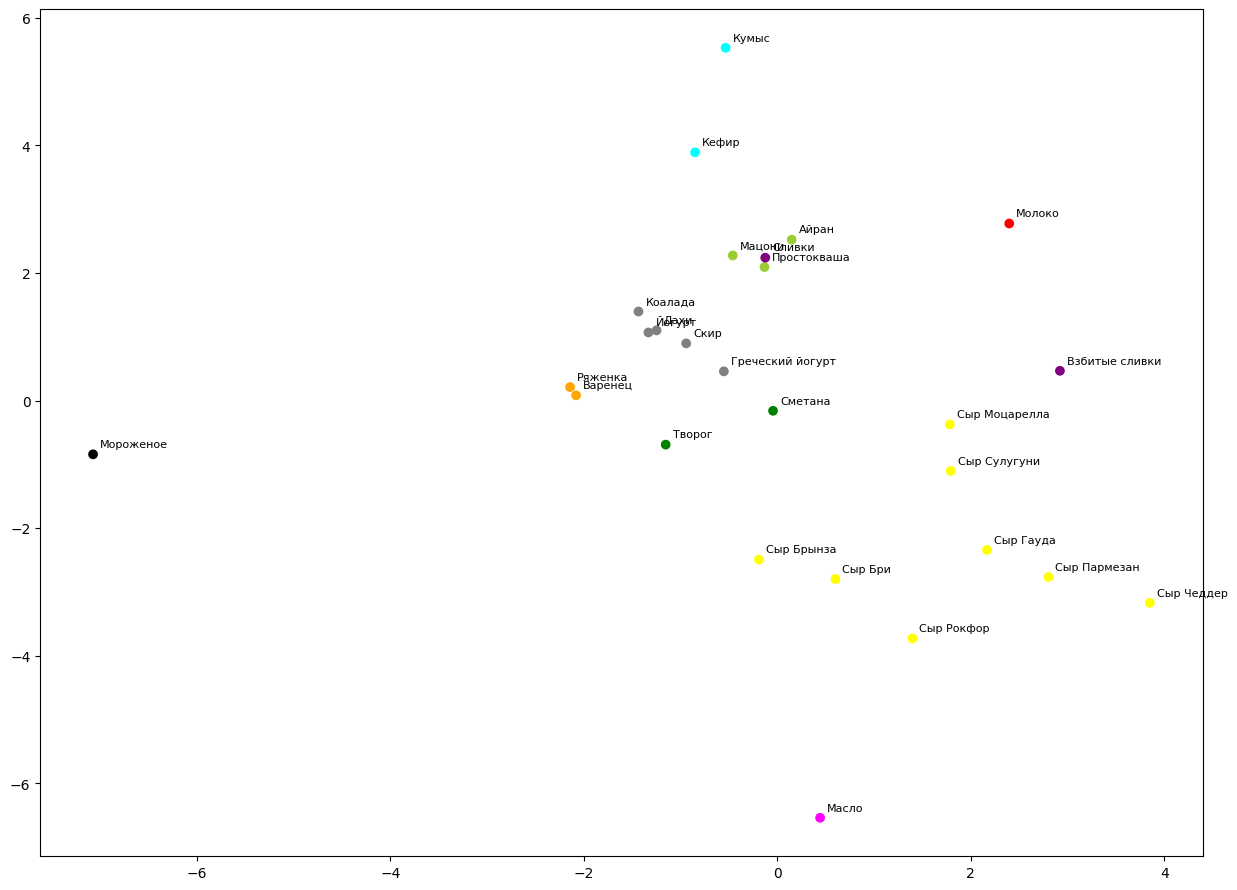

In [31]:
plt.figure(figsize=(15, 11))
plt.scatter(table_for_mds['x'], table_for_mds['y'], c=table_for_mds['color'])
for i, label in enumerate(table_for_mds['labels']):
    plt.annotate(table_for_mds['labels'][i], (table_for_mds['x'][i], table_for_mds['y'][i]), xytext=(5,5), textcoords='offset points', fontsize=8)
#plt.savefig('01_mds_milk_mpl.jpg', bbox_inches='tight')
plt.show()

In [32]:
# same operations for PCA
pca = decomposition.PCA(n_components=2)
pca_proc = pca.fit_transform(transformed)
print(pca_proc.shape)
ordination_pca = pd.DataFrame(pca_proc, columns=['x', 'y'])
ordination_pca['labels'] = labels
ordination_pca['group'] = ordination_pca['labels'].map(dict_milk_groups)
ordination_pca['color'] = ordination_pca['group'].map(dict_groups_colors)
ordination_pca.head()

(27, 2)


,x,y,labels,group,color
0,0.256933,-0.149990,Творог,сметана-творог,green
1,-0.000049,-0.138748,Сметана,сметана-творог,green
2,2.103635,-0.432902,Мацони,типа мацони,yellowgreen
3,1.010530,0.221189,Ряженка,типа ряженки,orange
4,0.889315,0.225031,Варенец,типа ряженки,orange


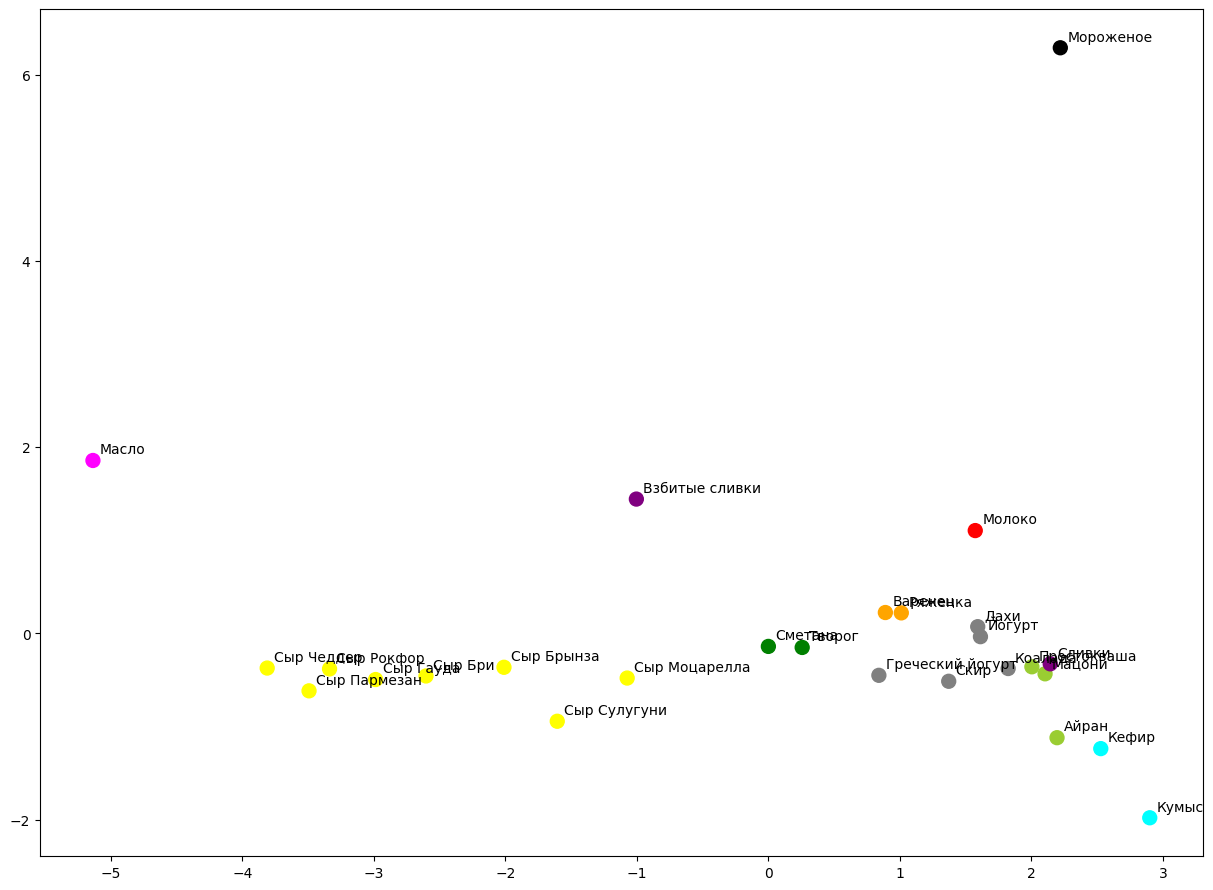

In [33]:
plt.figure(figsize=(15, 11))
plt.scatter(ordination_pca['x'], ordination_pca['y'], c=ordination_pca['color'], s=100)
for i, label in enumerate(ordination_pca['labels']):
    plt.annotate(ordination_pca['labels'][i], (ordination_pca['x'][i], ordination_pca['y'][i]), xytext=(5,5), textcoords='offset points', fontsize=10)
plt.savefig('02_pictures/02_pca_milk.jpg', bbox_inches='tight')
plt.show()

C:\Users\vladk\AppData\Local\Temp\ipykernel_6356\1369303498.py:11: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  dendrogram = scipy.cluster.hierarchy.dendrogram(scipy.cluster.hierarchy.linkage(pairwise_distances, method='ward'), labels=transformed.index)


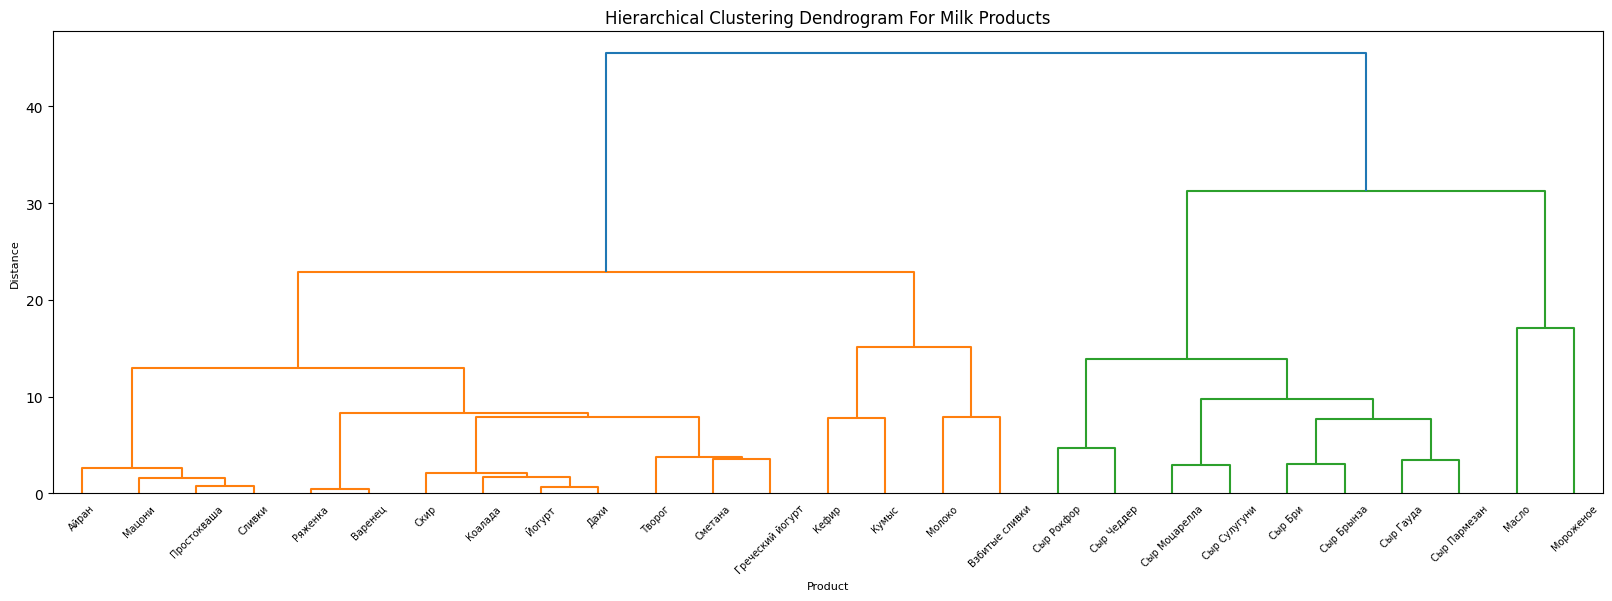

In [34]:
# Hierarchical clustering

# calculate pairwise distances
pairwise_distances = squareform(pdist(transformed, metric='euclidean'))

# hierarchical Clustering
#clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage='ward').fit(pairwise_distances)


plt.figure(figsize=(20, 6))
dendrogram = scipy.cluster.hierarchy.dendrogram(scipy.cluster.hierarchy.linkage(pairwise_distances, method='ward'), labels=transformed.index)
plt.title('Hierarchical Clustering Dendrogram For Milk Products')
plt.xlabel('Product', fontsize=8)
plt.tick_params(axis='x', labelsize=7, rotation=45)
plt.ylabel('Distance', fontsize=8)
#plt.savefig('03_cluster_milk.jpg', bbox_inches='tight')
plt.show()

<Figure size 1200x2000 with 0 Axes>

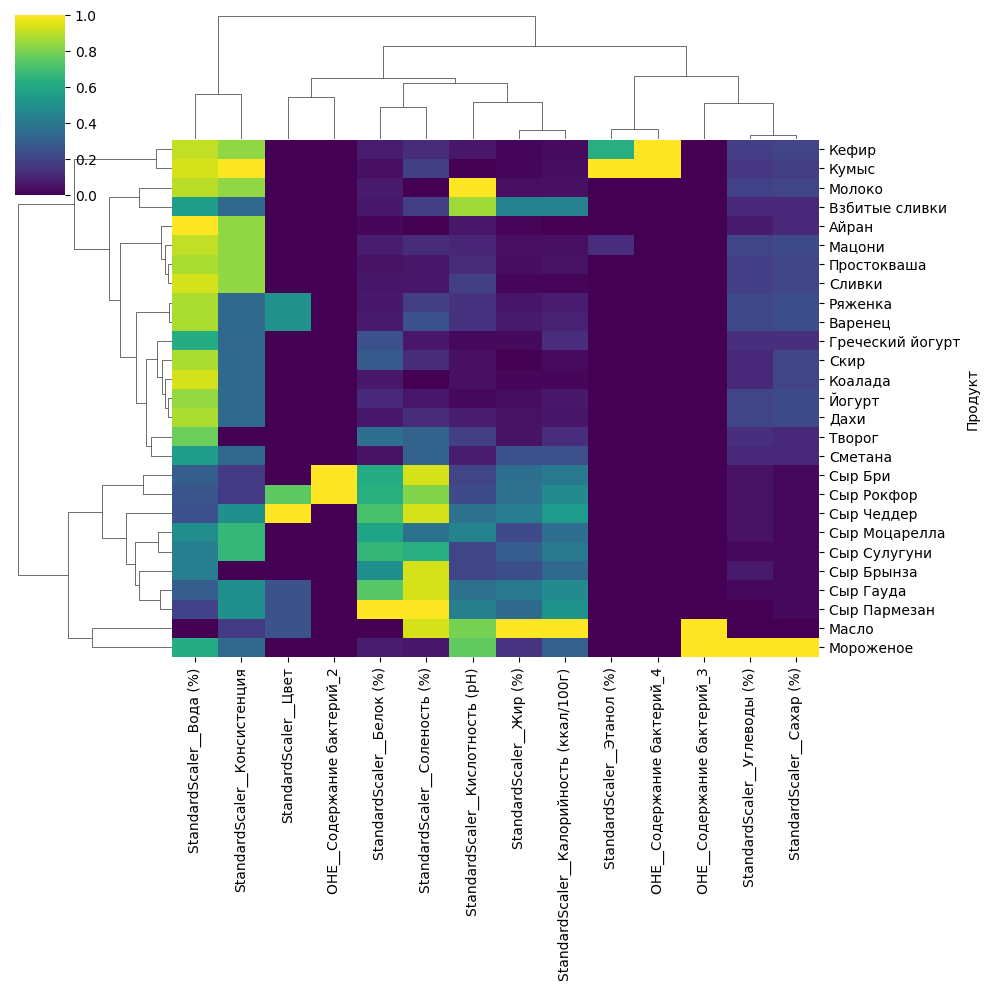

In [35]:
# Clustermap

# here clustermap for reflect relathionships between features and products
plt.figure(figsize=(12, 20))
sns.clustermap(transformed, method="ward", 
               metric="euclidean", 
               standard_scale=1,
               cmap='viridis')
# plt.savefig('04_clustermap_milk.jpg', bbox_inches='tight')
plt.show()

## MDS
here not only MDS but also PCA, clutermap and cluster tree from alcohol products data

In [36]:
data = pd.read_excel('01_support_data/alcohol_products_table_r.xlsx', index_col=[0])
labels = data.index
data.head()

,Цвет,Калорийность (ккал/100 мл),Сахар (г/100 мл),Крепость (%),Кислотность (pH),Естественное брожение,Газированность,Исходный продукт
Продукт,,,,,,,,
Красное вино,7,82.5,1.25,13.50,3.45,Да,Нет,Виноград
Белое вино,2,77.5,1.00,12.50,3.15,Да,Нет,Виноград
Сидр,4,57.5,3.00,5.50,3.55,Да,Низкая,Яблоки
Чача,1,225.0,0.00,50.00,3.50,Дистиляция,Нет,Виноград
Кефир,0,57.5,4.50,1.25,4.40,Да,Низкая,Молоко


In [37]:
# to preprocess most of the data I use square root transformation (for numeric cols or categorical which have rank) column 'Bacterial Content' is categorical feature without rank thus here I use OHE
from sklearn.preprocessing import StandardScaler, FunctionTransformer

ct = ColumnTransformer(
    [("Square_root", FunctionTransformer(np.sqrt), data.columns.drop(['Естественное брожение', 'Газированность', 'Исходный продукт']).to_list()),
     ("OHE", OneHotEncoder(drop='first'), ['Естественное брожение', 'Газированность', 'Исходный продукт'])])

transformed = pd.DataFrame(data=ct.fit_transform(data), index=labels)#, columns=ct.get_feature_names_out())
transformed.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Продукт,,,,,,,,,,,,,,,,
Красное вино,2.645751,9.082951,1.118034,3.674235,1.857418,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Белое вино,1.414214,8.803408,1.000000,3.535534,1.774824,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Сидр,2.000000,7.582875,1.732051,2.345208,1.884144,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
Чача,1.000000,15.000000,0.000000,7.071068,1.870829,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Кефир,0.000000,7.582875,2.121320,1.118034,2.097618,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [38]:
dict_alk_groups = {'Красное вино':'вино',
                   'Белое вино':'вино',
                   'Молодое вино':'вино',
                   'Сидр':'пиво',
                   'Лагер':'пиво',
                   'ИПА':'пиво',
                   'Квас':'пиво',
                   'Самогон':'самогон',
                   'Чача':'самогон',
                   'Граппа':'самогон',
                   'Виски':'самогон',
                   'Текилла':'самогон',
                   'Водка':'водка',
                   'Аквавит':'водка',
                   'Кефир':'кефир'}

dict_groups_colors = {'вино':'#7B0323',
                       'пиво' : 'gold',
                       'самогон': 'lime',
                       'водка': 'red',
                       'кефир': 'cyan'}

In [39]:
# here i made table for MDS
embedding = MDS(n_components=2, dissimilarity='precomputed')
table_for_mds = embedding.fit_transform(squareform(pdist(transformed, metric='braycurtis')))
table_for_mds = pd.DataFrame(table_for_mds)
table_for_mds.columns = ['x', 'y']
table_for_mds['labels'] = labels
table_for_mds['group'] = table_for_mds['labels'].map(dict_alk_groups)
table_for_mds['color'] = table_for_mds['group'].map(dict_groups_colors)
table_for_mds.head()

,x,y,labels,group,color
0,0.052056,0.090380,Красное вино,вино,#7B0323
1,0.038970,0.078310,Белое вино,вино,#7B0323
2,-0.125220,0.176540,Сидр,пиво,gold
3,0.064730,-0.207432,Чача,самогон,lime
4,-0.299443,0.095928,Кефир,кефир,cyan


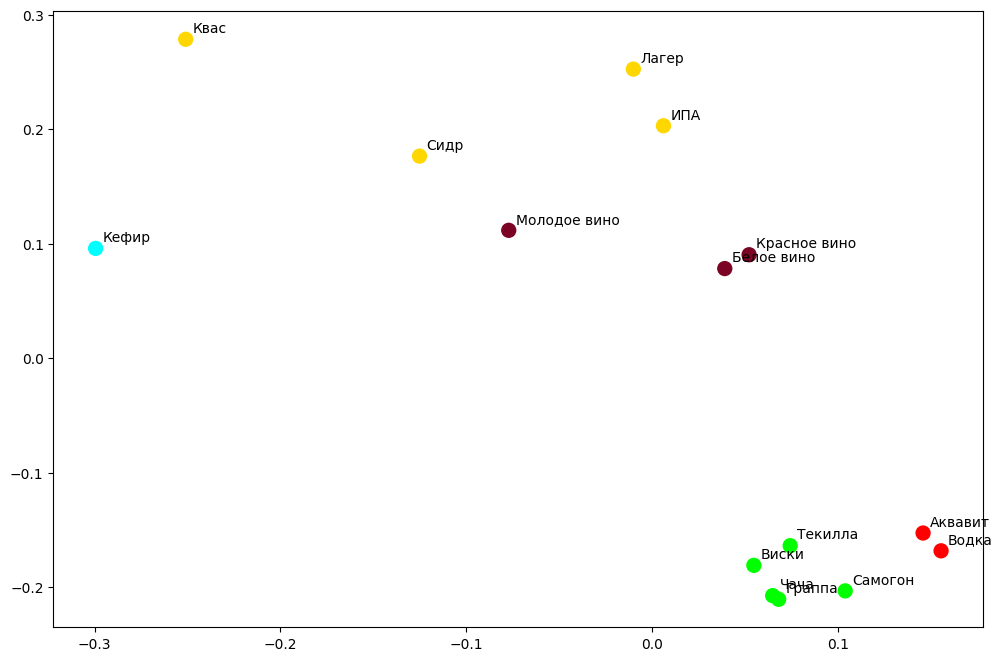

In [40]:
plt.figure(figsize=(12, 8))
plt.scatter(table_for_mds['x'], table_for_mds['y'], c=table_for_mds['color'], s=100)
for i, label in enumerate(table_for_mds['labels']):
    plt.annotate(table_for_mds['labels'][i], (table_for_mds['x'][i], table_for_mds['y'][i]), xytext=(5,5), textcoords='offset points', fontsize=10)
plt.savefig('02_pictures/03_mds_alko.jpg', bbox_inches='tight')
plt.show()

C:\Users\vladk\AppData\Local\Temp\ipykernel_6356\2986396518.py:11: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  dendrogram = scipy.cluster.hierarchy.dendrogram(scipy.cluster.hierarchy.linkage(pairwise_distances, method='ward'), labels=transformed.index)


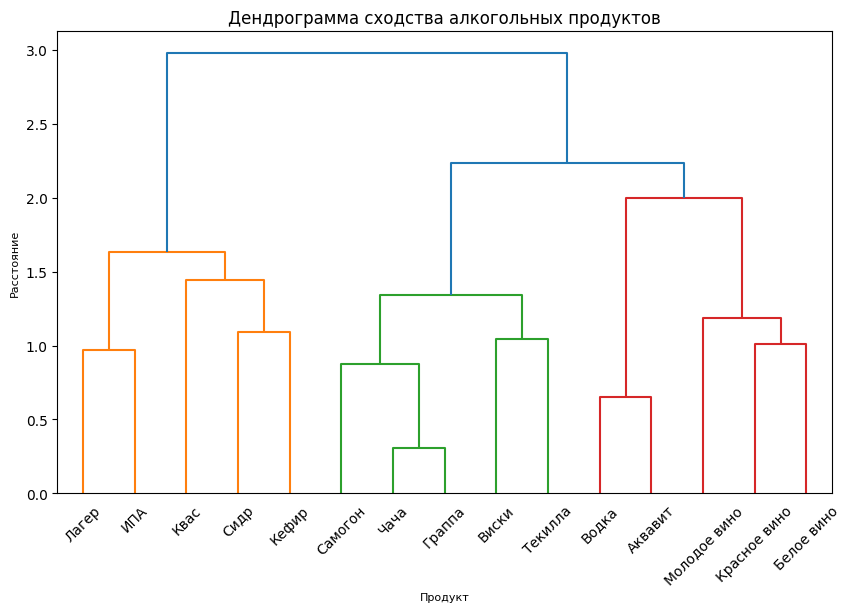

In [41]:
# Hierarchical clustering

# calculate pairwise distances
pairwise_distances = squareform(pdist(transformed, metric='jaccard'))

# hierarchical Clustering
#clustering = AgglomerativeClustering(n_clusters=None, distance_threshold=0, linkage='ward').fit(pairwise_distances)


plt.figure(figsize=(10, 6))
dendrogram = scipy.cluster.hierarchy.dendrogram(scipy.cluster.hierarchy.linkage(pairwise_distances, method='ward'), labels=transformed.index)
plt.title('Дендрограмма сходства алкогольных продуктов')
plt.xlabel('Продукт', fontsize=8)
plt.tick_params(axis='x', labelsize=10, rotation=45)
plt.ylabel('Расстояние', fontsize=8)
plt.savefig('02_pictures/04_cluster_alko.jpg', bbox_inches='tight')
plt.show()

<Figure size 1200x1200 with 0 Axes>

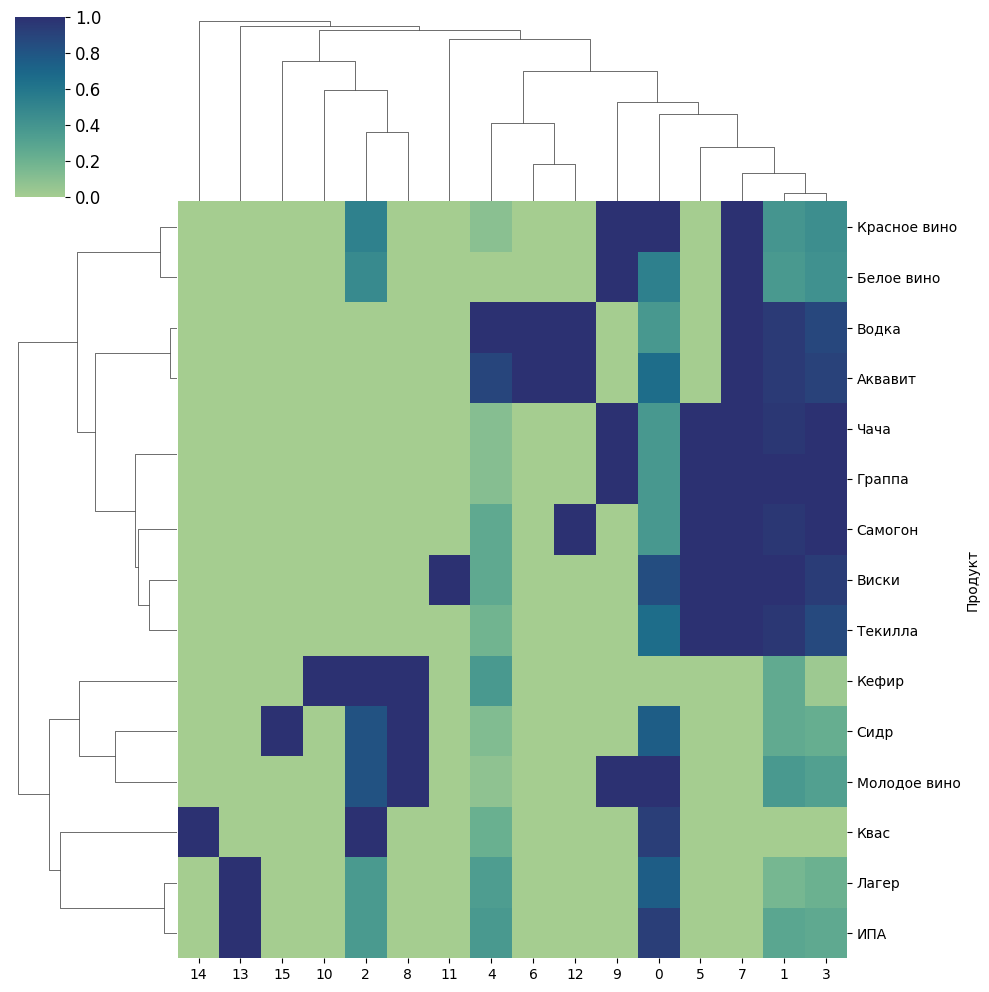

In [42]:
# Clustermap 

plt.figure(figsize=(12, 12))
sns.clustermap(transformed, method="average", 
               metric="braycurtis", 
               standard_scale=1,
               cmap='crest')
#plt.xlabel('Признаки', fontsize=14)
#plt.ylabel('Продукт', fontsize=14)
plt.xticks(fontsize = 12, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)
plt.savefig('02_pictures/05_clustermap_alco.jpg', bbox_inches='tight')
plt.show()

## Few ordinations with environmental data

### Making one analysis using different environmental data: presence/abscene, abundance, biomass, joined parameter

In [43]:
dict_groups_colors = {'Обская губа основная':'navy',
                      'Пресноводные': 'magenta',
                      'Море': 'lime',
                      'Переходная группа 1': 'red',
                      'Переходная группа 11':'cyan'}

In [44]:
k12_comm = pd.read_excel('01_support_data/Kara_2012_east_for_2025_pres.xlsx', sheet_name='comm',index_col=[0]).T
k12_comm.head()

station,community
4999,Море
5000,Море
5001,Море
5002,Море
5003,Море


In [48]:
k12_r = pd.read_excel('01_support_data/Kara_2012_east_for_2025_pres.xlsx', sheet_name='R_east',index_col=[0]).T
k12_r.columns = [i + '_r' for i in k12_r.columns]
col_save = k12_r.columns
k12_r.head()

,Tealia felina_r,Edwardsia sp._r,Paraedwardsia arenaria_r,Cerianthus lloydi_r,Alcionacea sp.A_r,Alcionacea sp.B_r,Actinia sp._r,Nemertini gen.sp._r,Amage auricula_r,Ampharete acutifrons_r,...,Diastylis rathkei_r,Leptostylis ampulacea_r,Leucon nasica_r,Pleurogonium inerme_r,Pleurogonium rubicundum_r,Balanus crenatus_r,Pagurus pubescens_r,Hyas araneus_r,Monoculopsis longicornis_r,Cucumaria glacialis_r
4999,0.012608,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.012173,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5000,0.005559,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000208,0.00000,0.004426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000568,0.00000,0.000100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002,0.125625,0.0,0.000246,0.0,0.0,0.000000,0.001137,0.055841,0.00000,0.000660,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5003,0.000000,0.0,0.000000,0.0,0.0,0.000898,0.000069,0.009199,0.00312,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [49]:
sqrtran = FunctionTransformer(np.sqrt)
k12_r = sqrtran.fit_transform(k12_r)
k12_r.columns = col_save
k12_r.head()

,Tealia felina_r,Edwardsia sp._r,Paraedwardsia arenaria_r,Cerianthus lloydi_r,Alcionacea sp.A_r,Alcionacea sp.B_r,Actinia sp._r,Nemertini gen.sp._r,Amage auricula_r,Ampharete acutifrons_r,...,Diastylis rathkei_r,Leptostylis ampulacea_r,Leucon nasica_r,Pleurogonium inerme_r,Pleurogonium rubicundum_r,Balanus crenatus_r,Pagurus pubescens_r,Hyas araneus_r,Monoculopsis longicornis_r,Cucumaria glacialis_r
4999,0.112286,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.110333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5000,0.074559,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.014430,0.000000,0.066528,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.023842,0.000000,0.010024,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002,0.354436,0.0,0.015677,0.0,0.0,0.000000,0.033716,0.236308,0.000000,0.025695,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5003,0.000000,0.0,0.000000,0.0,0.0,0.029966,0.008312,0.095911,0.055859,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
k12_n = pd.read_excel('01_support_data/Kara_2012_east_for_2025_pres.xlsx', sheet_name='N_east',index_col=[0]).T
k12_n.columns = [i + '_ab' for i in k12_n.columns]
col_save = k12_n.columns
united_raw = k12_r.join(k12_n)

sqrtran = FunctionTransformer(np.sqrt)
k12_n = sqrtran.fit_transform(k12_n)
k12_n.columns = col_save

k12_n.head()

,Tealia felina_ab,Edwardsia sp._ab,Paraedwardsia arenaria_ab,Cerianthus lloydi_ab,Alcionacea sp.A_ab,Alcionacea sp.B_ab,Actinia sp._ab,Nemertini gen.sp._ab,Amage auricula_ab,Ampharete acutifrons_ab,...,Diastylis rathkei_ab,Leptostylis ampulacea_ab,Leucon nasica_ab,Pleurogonium inerme_ab,Pleurogonium rubicundum_ab,Balanus crenatus_ab,Pagurus pubescens_ab,Hyas araneus_ab,Monoculopsis longicornis_ab,Cucumaria glacialis_ab
4999,1.414214,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,4.472136,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5000,1.414214,0.0,0.00000,0.0,0.0,0.000000,0.000000,2.449490,0.000000,2.828427,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,2.000000,0.000000,1.414214,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002,2.000000,0.0,2.44949,0.0,0.0,0.000000,3.162278,8.366600,0.000000,2.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5003,0.000000,0.0,0.00000,0.0,0.0,1.414214,2.000000,4.472136,4.472136,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
k12_b = pd.read_excel('01_support_data/Kara_2012_east_for_2025_pres.xlsx', sheet_name='B_east',index_col=[0]).T
k12_b.columns = [i + '_b' for i in k12_b.columns]
col_save = k12_b.columns
united_raw = united_raw.join(k12_b)

sqrtran = FunctionTransformer(np.sqrt)
k12_b = sqrtran.fit_transform(k12_b)
k12_b.columns = col_save

k12_b.head()

,Tealia felina_b,Edwardsia sp._b,Paraedwardsia arenaria_b,Cerianthus lloydi_b,Alcionacea sp.A_b,Alcionacea sp.B_b,Actinia sp._b,Nemertini gen.sp._b,Amage auricula_b,Ampharete acutifrons_b,...,Diastylis rathkei_b,Leptostylis ampulacea_b,Leucon nasica_b,Pleurogonium inerme_b,Pleurogonium rubicundum_b,Balanus crenatus_b,Pagurus pubescens_b,Hyas araneus_b,Monoculopsis longicornis_b,Cucumaria glacialis_b
4999,2.143362,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.487852,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5000,1.983935,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.063246,0.000000,0.462601,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5001,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.126491,0.000000,0.044721,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5002,4.325968,0.0,0.063246,0.0,0.000000,0.000000,0.161245,0.534790,0.000000,0.044721,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5003,0.000000,0.0,0.000000,0.0,0.814862,0.392428,0.063246,0.431277,0.209762,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
k12_pa = pd.read_excel('01_support_data/Kara_2012_east_for_2025_pres.xlsx', sheet_name='+-_east',index_col=[0]).T
k12_pa.columns = [i + '_pa' for i in k12_pa.columns]
united_raw = united_raw.join(k12_pa)
k12_pa.head()

,Tealia felina_pa,Edwardsia sp._pa,Paraedwardsia arenaria_pa,Cerianthus lloydi_pa,Alcionacea sp.A_pa,Alcionacea sp.B_pa,Actinia sp._pa,Nemertini gen.sp._pa,Amage auricula_pa,Ampharete acutifrons_pa,...,Diastylis rathkei_pa,Leptostylis ampulacea_pa,Leucon nasica_pa,Pleurogonium inerme_pa,Pleurogonium rubicundum_pa,Balanus crenatus_pa,Pagurus pubescens_pa,Hyas araneus_pa,Monoculopsis longicornis_pa,Cucumaria glacialis_pa
4999,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5000,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5001,0,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5002,1,0,1,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
5003,0,0,0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [53]:
united = k12_r.join(k12_n)
united = united.join(k12_b)
united = united.join(k12_pa)
united.head()

,Tealia felina_r,Edwardsia sp._r,Paraedwardsia arenaria_r,Cerianthus lloydi_r,Alcionacea sp.A_r,Alcionacea sp.B_r,Actinia sp._r,Nemertini gen.sp._r,Amage auricula_r,Ampharete acutifrons_r,...,Diastylis rathkei_pa,Leptostylis ampulacea_pa,Leucon nasica_pa,Pleurogonium inerme_pa,Pleurogonium rubicundum_pa,Balanus crenatus_pa,Pagurus pubescens_pa,Hyas araneus_pa,Monoculopsis longicornis_pa,Cucumaria glacialis_pa
4999,0.112286,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.110333,...,0,0,0,0,0,0,0,0,0,0
5000,0.074559,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.014430,0.000000,0.066528,...,0,0,0,0,0,0,0,0,0,0
5001,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.023842,0.000000,0.010024,...,0,0,0,0,0,0,0,0,0,0
5002,0.354436,0.0,0.015677,0.0,0.0,0.000000,0.033716,0.236308,0.000000,0.025695,...,0,0,0,0,0,0,0,0,0,0
5003,0.000000,0.0,0.000000,0.0,0.0,0.029966,0.008312,0.095911,0.055859,0.000000,...,0,0,0,0,0,0,0,0,0,0


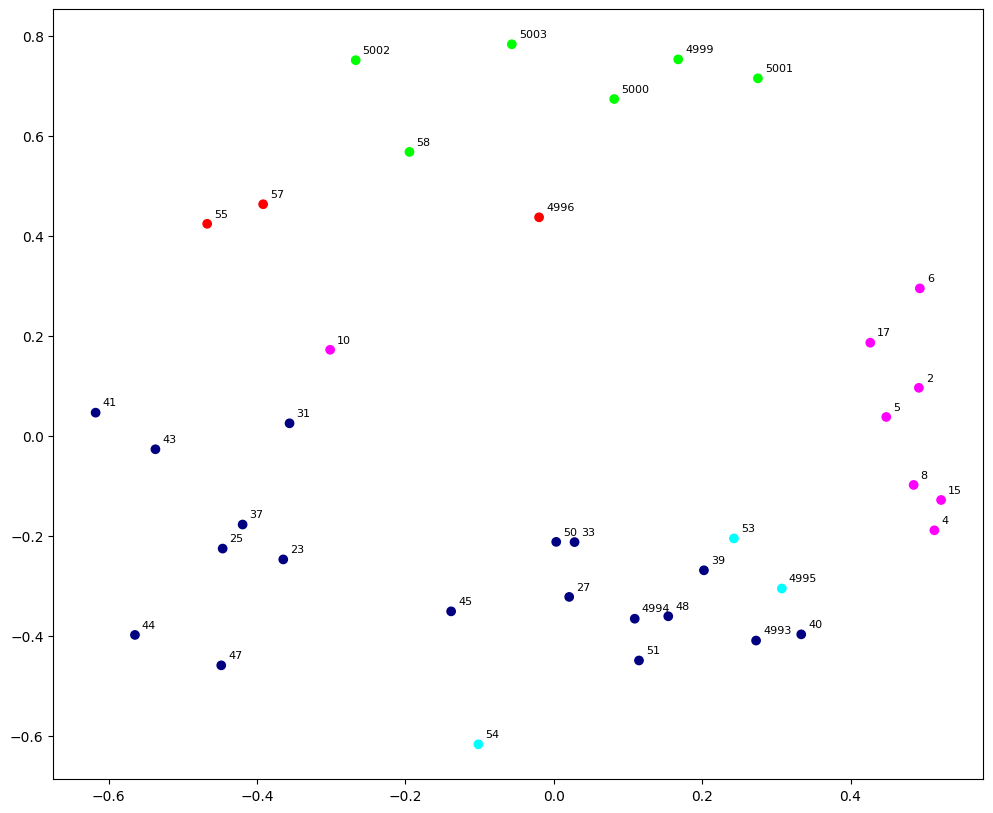

In [54]:
embedding = MDS(n_components=2, dissimilarity='precomputed')
table_for_mds = embedding.fit_transform(squareform(pdist(united, metric='braycurtis')))
table_for_mds = pd.DataFrame(table_for_mds)
table_for_mds.columns = ['x', 'y']
table_for_mds['community'] = list(k12_comm['community'])
table_for_mds['station'] = list(k12_comm.index)
#table_for_mds['group'] = table_for_mds['labels'].map(dict_milk_groups)
table_for_mds['color'] = table_for_mds['community'].map(dict_groups_colors)
table_for_mds.head()

plt.figure(figsize=(12, 10))
plt.scatter(table_for_mds['x'], table_for_mds['y'], c=table_for_mds['color'])
for i, label in enumerate(table_for_mds['station']):
    plt.annotate(table_for_mds['station'][i], (table_for_mds['x'][i], table_for_mds['y'][i]), xytext=(5,5), textcoords='offset points', fontsize=8)
#plt.savefig('01_mds_milk_mpl.jpg', bbox_inches='tight')
plt.show()

### TSNE-UMAP-PCA_MDS

In [56]:
from sklearn.manifold import TSNE
import umap

C:\Users\vladk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [57]:
dict_markers_from_colors = {'navy':'v',
                      'magenta': 'o',
                      'lime': 'o',
                      'red': 'D',
                      'cyan':'s'}

In [58]:
embedding = MDS(n_components=2, dissimilarity='precomputed')
table_for_mds = embedding.fit_transform(squareform(pdist(k12_r, metric='braycurtis')))
table_for_mds = pd.DataFrame(table_for_mds)
table_for_mds.columns = ['X', 'Y']
table_for_mds['community'] = list(k12_comm['community'])
table_for_mds['station'] = list(k12_comm.index)
table_for_mds['color'] = table_for_mds['community'].map(dict_groups_colors)
table_for_mds['marker'] = table_for_mds['color'].map(dict_markers_from_colors)
table_for_mds.head()

,X,Y,community,station,color,marker
0,-0.643791,-0.383820,Море,4999,lime,o
1,-0.328852,-0.688698,Море,5000,lime,o
2,-0.498842,-0.563252,Море,5001,lime,o
3,-0.634008,-0.457556,Море,5002,lime,o
4,-0.754074,-0.219573,Море,5003,lime,o


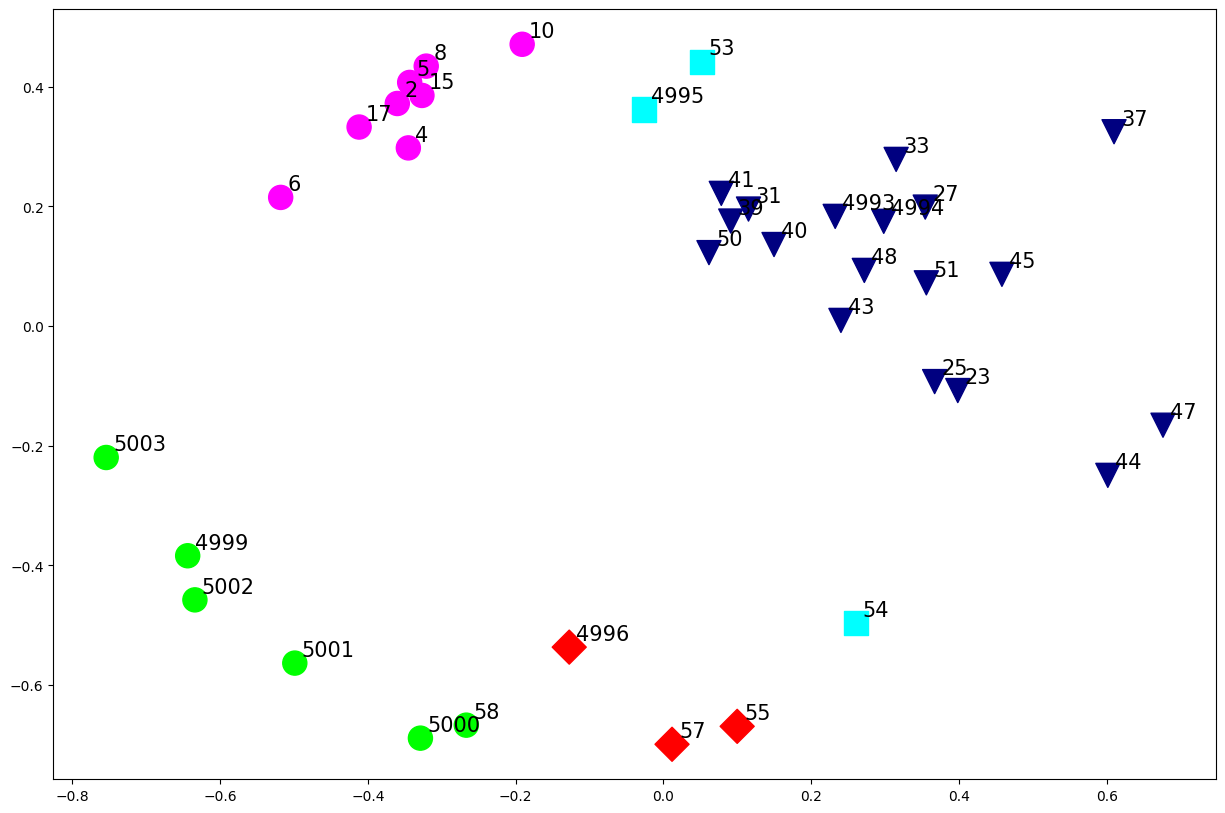

In [59]:
plt.figure(figsize=(15, 10))
for a in table_for_mds['community'].unique():
    subset = table_for_mds.loc[table_for_mds['community']==a]
    e = np.unique(subset['marker'])[0]
    plt.scatter(subset['X'], subset['Y'], c=subset['color'], s=300, marker=e)

for i, label in enumerate(table_for_mds['station']):
    plt.annotate(table_for_mds['station'][i], (table_for_mds['X'][i], table_for_mds['Y'][i]), xytext=(5,5), textcoords='offset points', fontsize=15)
plt.savefig('02_pictures/06_k12_r_mds.jpg', bbox_inches='tight')
plt.show()

In [60]:
pca = decomposition.PCA(n_components=2)
pca_proc = pca.fit_transform(k12_r)
print(pca_proc.shape)
ordination_pca = pd.DataFrame(pca_proc, columns=['X', 'Y'])
ordination_pca['community'] = list(k12_comm['community'])
ordination_pca['station'] = list(k12_comm.index)
ordination_pca['color'] = ordination_pca['community'].map(dict_groups_colors)
ordination_pca['marker'] = ordination_pca['color'].map(dict_markers_from_colors)
ordination_pca.head()

(38, 2)


,X,Y,community,station,color,marker
0,-0.664014,-0.249012,Море,4999,lime,o
1,-0.851268,-0.306456,Море,5000,lime,o
2,-0.708170,-0.263670,Море,5001,lime,o
3,-0.490754,-0.175626,Море,5002,lime,o
4,-0.562914,-0.203359,Море,5003,lime,o


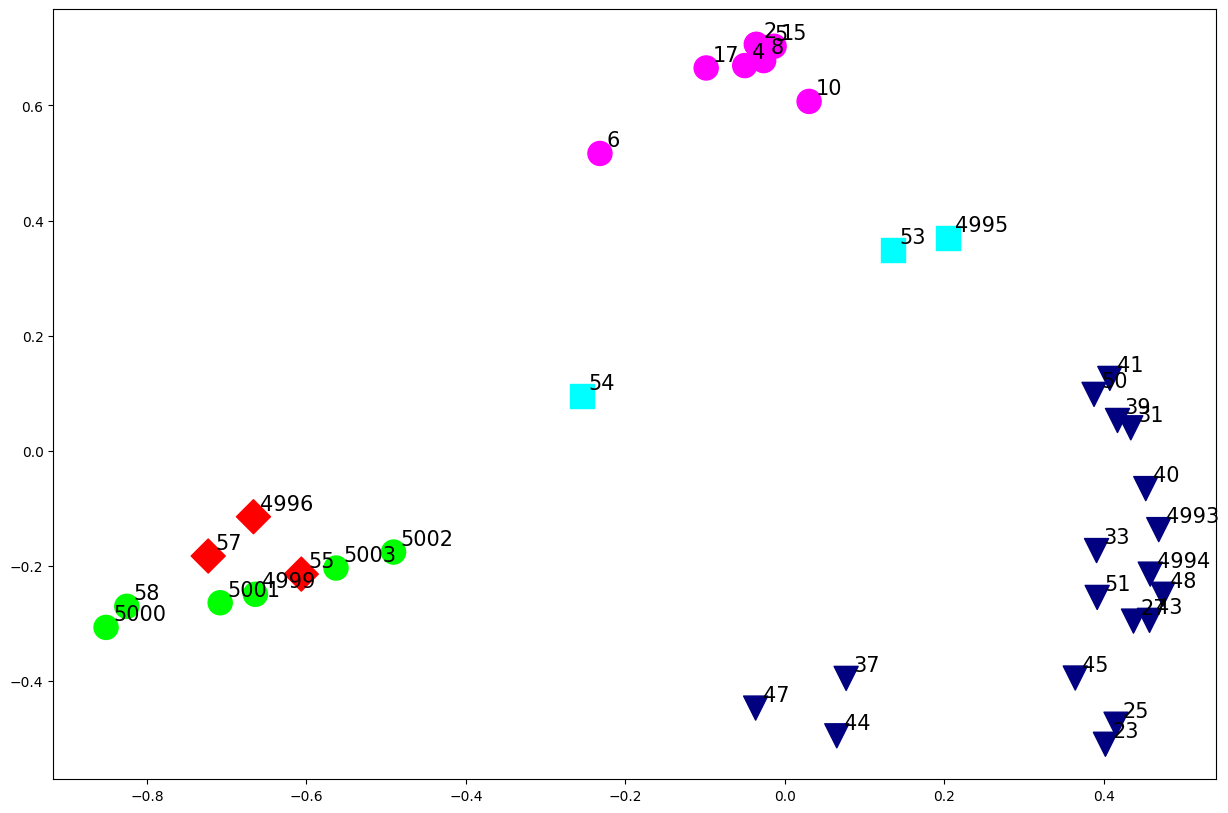

In [61]:
plt.figure(figsize=(15, 10))
for a in ordination_pca['community'].unique():
    subset = ordination_pca.loc[ordination_pca['community']==a]
    e = np.unique(subset['marker'])[0]
    plt.scatter(subset['X'], subset['Y'], c=subset['color'], s=300, marker=e)

for i, label in enumerate(ordination_pca['station']):
    plt.annotate(ordination_pca['station'][i], (ordination_pca['X'][i], ordination_pca['Y'][i]), xytext=(5,5), textcoords='offset points', fontsize=15)
plt.savefig('02_pictures/07_k12_r_pca.jpg', bbox_inches='tight')
plt.show()

In [62]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(k12_r)
embedding.shape
ordination_umap = pd.DataFrame(embedding, columns=['X', 'Y'])
ordination_umap['community'] = list(k12_comm['community'])
ordination_umap['station'] = list(k12_comm.index)
ordination_umap['color'] = ordination_umap['community'].map(dict_groups_colors)
ordination_umap['marker'] = ordination_umap['color'].map(dict_markers_from_colors)
ordination_umap.head()

,X,Y,community,station,color,marker
0,-1.957792,13.800959,Море,4999,lime,o
1,-1.341345,13.947402,Море,5000,lime,o
2,-1.688448,13.752306,Море,5001,lime,o
3,-1.805347,13.582207,Море,5002,lime,o
4,-1.690767,13.239528,Море,5003,lime,o


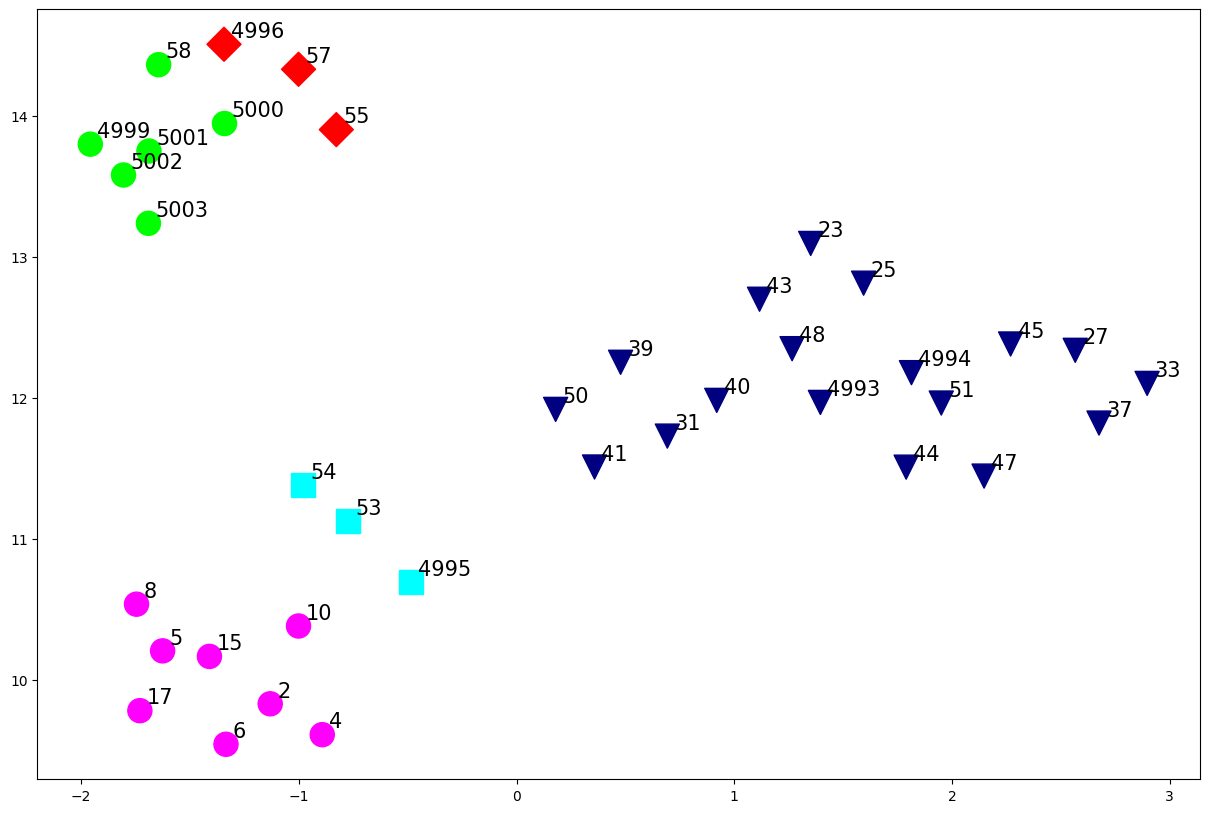

In [63]:
plt.figure(figsize=(15, 10))
for a in ordination_umap['community'].unique():
    subset = ordination_umap.loc[ordination_umap['community']==a]
    e = np.unique(subset['marker'])[0]
    plt.scatter(subset['X'], subset['Y'], c=subset['color'], s=300, marker=e)

for i, label in enumerate(ordination_umap['station']):
    plt.annotate(ordination_umap['station'][i], (ordination_umap['X'][i], ordination_umap['Y'][i]), xytext=(5,5), textcoords='offset points', fontsize=15)
plt.savefig('02_pictures/08_k12_r_umap.jpg', bbox_inches='tight')
plt.show()

In [64]:
tsne_proc = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(k12_r)
print(tsne_proc.shape)
ordination_tsne = pd.DataFrame(tsne_proc, columns=['X', 'Y']) 
ordination_tsne['community'] = list(k12_comm['community'])
ordination_tsne['station'] = list(k12_comm.index)
ordination_tsne['color'] = ordination_tsne['community'].map(dict_groups_colors)
ordination_tsne['marker'] = ordination_tsne['color'].map(dict_markers_from_colors)
ordination_tsne.head()

(38, 2)


,X,Y,community,station,color,marker
0,85.958199,-96.660210,Море,4999,lime,o
1,99.836975,-106.468689,Море,5000,lime,o
2,86.787224,-101.109573,Море,5001,lime,o
3,84.772209,-84.861717,Море,5002,lime,o
4,82.846924,-91.006493,Море,5003,lime,o


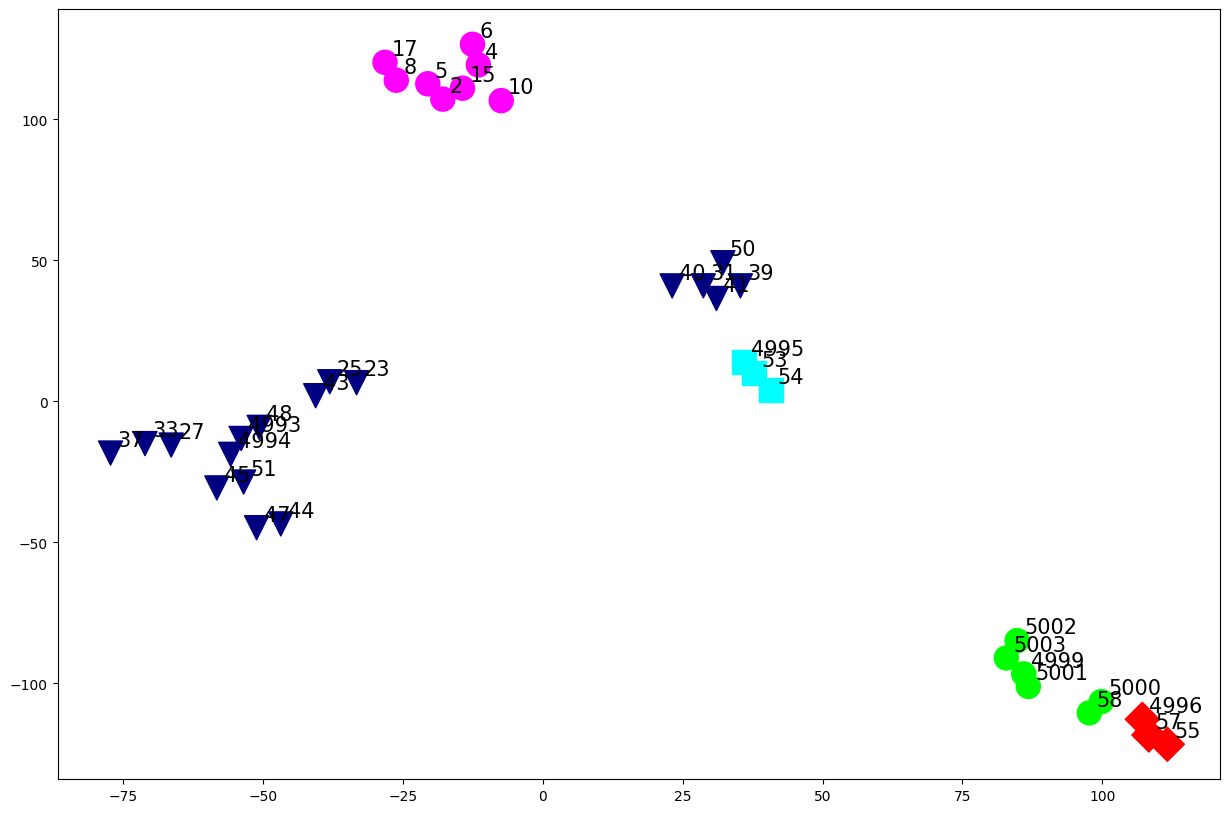

In [65]:
plt.figure(figsize=(15, 10))
for a in ordination_tsne['community'].unique():
    subset = ordination_tsne.loc[ordination_tsne['community']==a]
    e = np.unique(subset['marker'])[0]
    plt.scatter(subset['X'], subset['Y'], c=subset['color'], s=300, marker=e)

for i, label in enumerate(ordination_tsne['station']):
    plt.annotate(ordination_tsne['station'][i], (ordination_tsne['X'][i], ordination_tsne['Y'][i]), xytext=(5,5), textcoords='offset points', fontsize=15)
plt.savefig('02_pictures/09_k12_r_tsne.jpg', bbox_inches='tight')
plt.show()

## Most common plots (barplots, histplot, etc)

### Radar plot for wind

In [68]:
wind = pd.DataFrame({'direction': [0, 45, 90, 135,180, 225, 270, 315], 'frequency':[15, 6.8, 7.8,12.2, 12.6,14.6, 16.4,14.5]})
wind

,direction,frequency
0,0,15.0
1,45,6.8
2,90,7.8
3,135,12.2
4,180,12.6
5,225,14.6
6,270,16.4
7,315,14.5


C:\Users\vladk\AppData\Local\Temp\ipykernel_6356\1907199069.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(x)) + '%' for x in ax.get_yticks()])


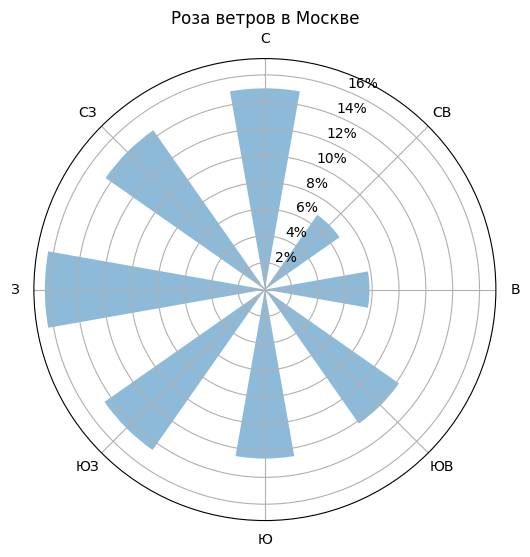

In [69]:
theta_deg = wind['direction'] 

# convert degrees to radians 
theta = np.deg2rad(theta_deg)

# polar axes
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6,6))

ax.set_theta_zero_location('N')  
ax.set_theta_direction(-1)       
width = np.deg2rad(20) 
ax.bar(theta, wind['frequency'], width=width, alpha=0.5, label='bar')
ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
ax.set_xticklabels(['С','СВ','В','ЮВ','Ю','ЮЗ','З','СЗ'])
ax.set_yticklabels([str(int(x)) + '%' for x in ax.get_yticks()])

ax.set_title('Роза ветров в Москве')
plt.savefig('02_pictures/10_wind.jpg')
plt.show()

### Lineplots

In [74]:
data = pd.read_excel('01_support_data/hydro.xlsx', header=[1])
data = data[['depth', 'temperature', 'salinity']]
data['depth'] = - data['depth']

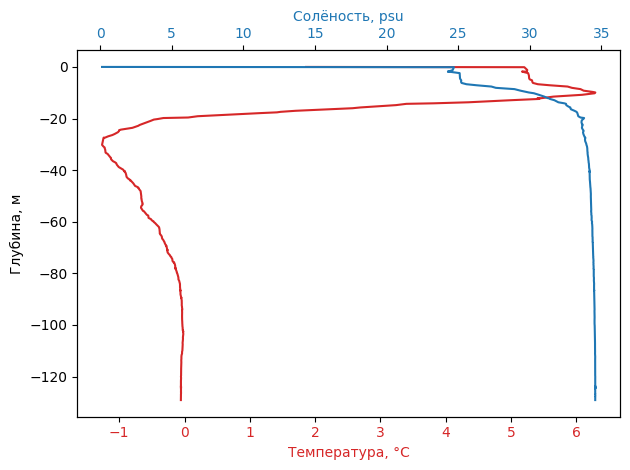

In [75]:
fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.set_ylabel('Глубина, м')
ax1.set_xlabel('Температура, °С', color=color)
ax1.plot(data['temperature'], data['depth'], color=color)
ax1.tick_params(axis='x', labelcolor=color)

ax2 = ax1.twiny()  

color = 'tab:blue'
ax2.set_xlabel('Солёность, psu', color=color)  
ax2.plot(data['salinity'], data['depth'], color=color)
ax2.tick_params(axis='x', labelcolor=color)

fig.tight_layout()  
plt.savefig('02_pictures/11_hydro.jpg')
plt.show()

In [ ]:
import xarray as xr

In [76]:
# due to problems with opening nc with cyrillic way here alternative way
ncdf_path = 'C:/Users/vladk/NC_DATA/lect/'

In [79]:
ds = xr.open_dataset(ncdf_path + 'ARCTIC_OMI_SI_extent_19790115_P20250505_R19792024.nc')
ds = ds.to_dataframe().reset_index()
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13248 entries, 0 to 13247
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   clim_months                      13248 non-null  datetime64[ns]
 1   nv                               13248 non-null  int64         
 2   time                             13248 non-null  datetime64[ns]
 3   clim_months_bounds               13248 non-null  int32         
 4   monthlyclimsiextent_mean         13248 non-null  float32       
 5   monthlyclimsiextent_std          13248 non-null  float32       
 6   sea_ice_area_fraction_threshold  13248 non-null  float32       
 7   siextent                         13152 non-null  float32       
 8   time_bounds                      13248 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float32(4), int32(1), int64(1)
memory usage: 672.9 KB


In [80]:
ds = ds[['time', 'siextent']]
ds['time'] = pd.to_datetime(ds['time']).dt.to_period('M').dt.to_timestamp()
ds = ds.sort_values(by='time').drop_duplicates()
ds

,time,siextent
0,1979-01-01,15445716.0
1657,1979-02-01,16146127.0
10490,1979-03-01,16374597.0
3,1979-04-01,15604021.0
6628,1979-05-01,14032036.0
...,...,...
1651,2024-08-01,5647520.0
1100,2024-09-01,4773854.0
3309,2024-10-01,6309818.5
6070,2024-11-01,9398292.0


In [81]:
ds = ds.set_index('time')
ds.index.is_monotonic_increasing

True

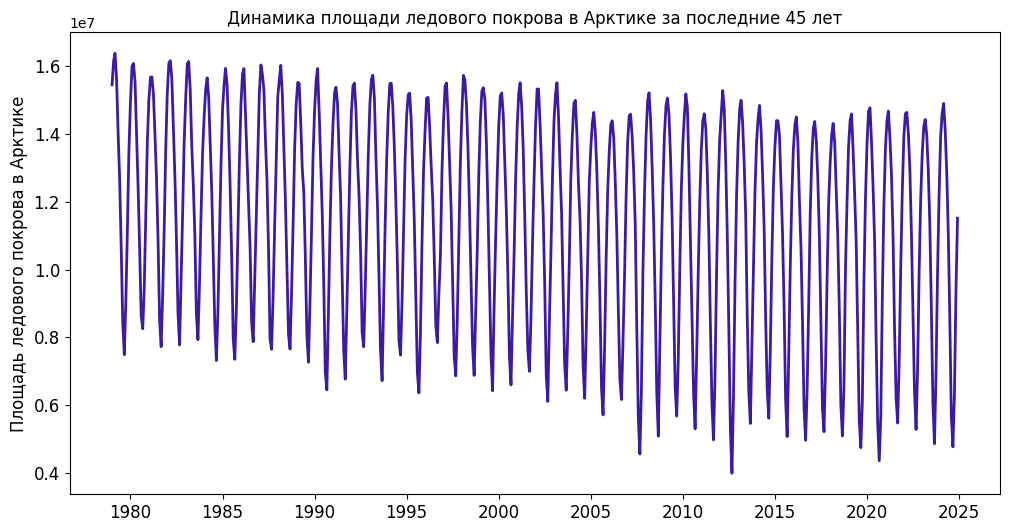

In [82]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=ds, x='time', y='siextent', color='#3C1BA3', linewidth=2)
plt.xlabel('', fontsize=14)
plt.ylabel('Площадь ледового покрова в Арктике', fontsize=12)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)
plt.title('Динамика площади ледового покрова в Арктике за последние 45 лет', fontsize = 12)
#plt.ylim(8.025,8.125)
plt.savefig('02_pictures/12_sea_ice_lineplot.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

In [83]:
ds = xr.open_dataset(ncdf_path + 'global_omi_tempsal_sst_area_averaged_anomalies_19820101-20241231_R19912020_P20250516.nc')
ds = ds.to_dataframe().reset_index()
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   time                  516 non-null    datetime64[ns]
 1   sst_anomaly           516 non-null    float32       
 2   sst_anomaly_filtered  504 non-null    float32       
dtypes: datetime64[ns](1), float32(2)
memory usage: 8.2 KB


In [84]:
ds = ds.set_index('time')
ds.index.is_monotonic_increasing

True

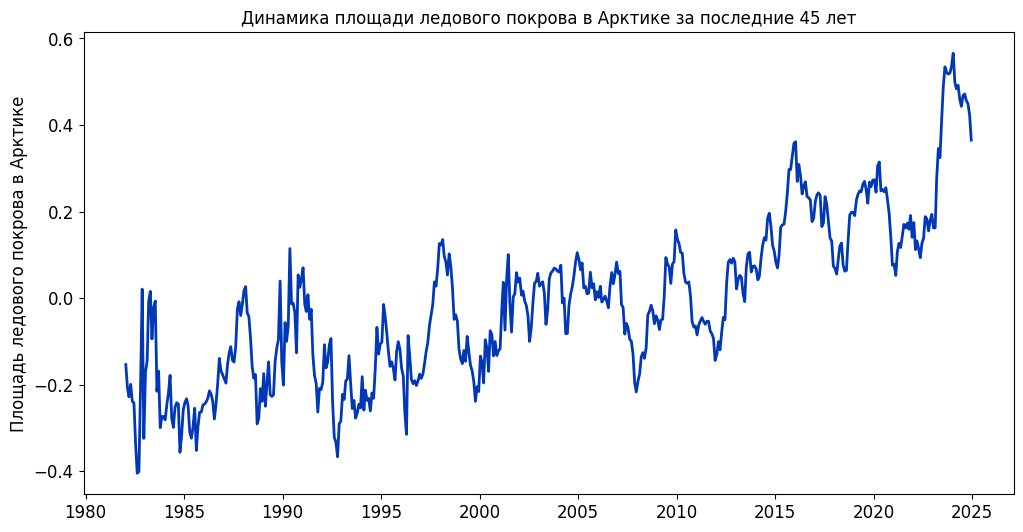

In [85]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=ds, x='time', y='sst_anomaly', color='#0038B8', linewidth=2)

plt.xlabel('', fontsize=14)
plt.ylabel('Площадь ледового покрова в Арктике', fontsize=12)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)
plt.title('Динамика площади ледового покрова в Арктике за последние 45 лет', fontsize = 12)
#plt.ylim(8.025,8.125)
plt.savefig('02_pictures/13_sea_ice_lineplot.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

### Barplots and pieplot 
i keep some inactive code for possible using in different cases

In [87]:
taxons = pd.read_excel('01_support_data/Kara_AMK_base.xls', sheet_name='b_for_visual_east_2', header=None)
taxons.columns = taxons.iloc[0]
def change_name(row):
    if row == 'Pantopoda' or row == 'Priapuloidea' or row == 'Sipuncoloidea' or row == 'Insecta' or row == 'Aplacophora' or row == 'Oligochaeta' or row == 'Echiuroidea' or row == 'Nemertini' or row == 'Bryozoa':
        return 'Other'
    else: 
        return row
taxons['Taxon'] = taxons['Taxon'].apply(change_name)
taxons.head()

,Taxon,Море,Море,Море,Море,Море,Обская основная,Обская основная,Переходная_юг,Переходная_север,...,Обская основная,Обская основная,Обская основная,Обская основная,Обская основная,Переходная_юг,Переходная_юг,Переходная_север,Переходная_север,Море
0,Taxon,Море,Море,Море,Море,Море,Обская основная,Обская основная,Переходная_юг,Переходная_север,...,Обская основная,Обская основная,Обская основная,Обская основная,Обская основная,Переходная_юг,Переходная_юг,Переходная_север,Переходная_север,Море
1,Anthozoa,4.594,3.936,0,18.714,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Anthozoa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.004,0,0
3,Anthozoa,0,0,0,0.004,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Anthozoa,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [89]:
b = taxons[1:].groupby('Taxon').agg(['sum']).reset_index()
b.columns = b.columns.droplevel(1)
b.index = b['Taxon']
d = b.T.reset_index()[1:].groupby(0).agg(['sum'])
d.columns = d.columns.droplevel(1)
d

Taxon,Anthozoa,Ascidiacea,Bivalvia,Crustacea,Echinodermata,Gastropoda,Other,Polychaeta
0,,,,,,,,
Море,28.096,0.076,327.623861,2.288,6.418,2.232,21.327333,32.429994
Обская основная,0,0,0.033333,143.718547,0,0,47.579216,276.073448
Переходная_север,0.004,0,36.636446,5.248,0,1.018,3.25733,5.760641
Переходная_юг,0,0,2.387333,11.722,0,0,47.514395,4.509299
Пресноводная,0,0,5.43,0.68,0,0,42.19,0


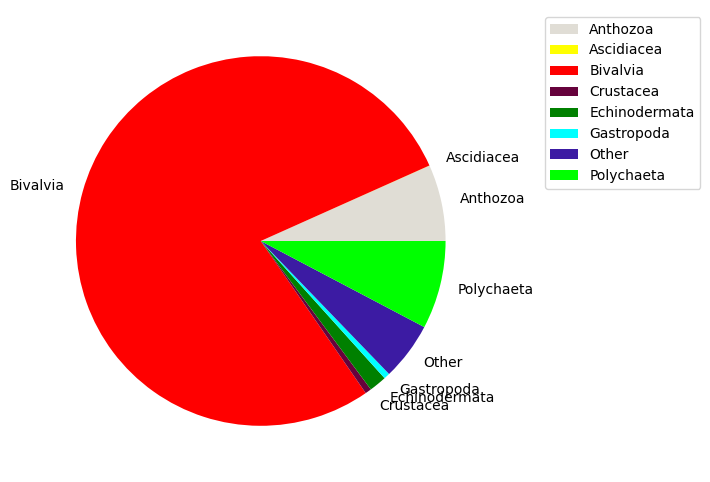

In [91]:
colors =  ['#e0ddd5', 'yellow', 'red',  '#66023C', 'green', 'cyan', '#3C1BA3', 'lime']

plt.figure(figsize=(10, 6)) 
#sns.set(context = 'notebook', style = 'whitegrid', font_scale=0.9)
#colors = sns.color_palette('husl')[ 0:5 ]
d3 = d.T.loc[d.T['Море'] > 0]
plt.pie(d3['Море'], labels = d3.index, colors = colors)#, autopct='%.0f%%')
plt.legend(loc='upper left', bbox_to_anchor=[1.1, 1])
plt.savefig('02_pictures/14_pieplot_kara.jpg',  bbox_inches='tight', pad_inches = 0)
plt.show()

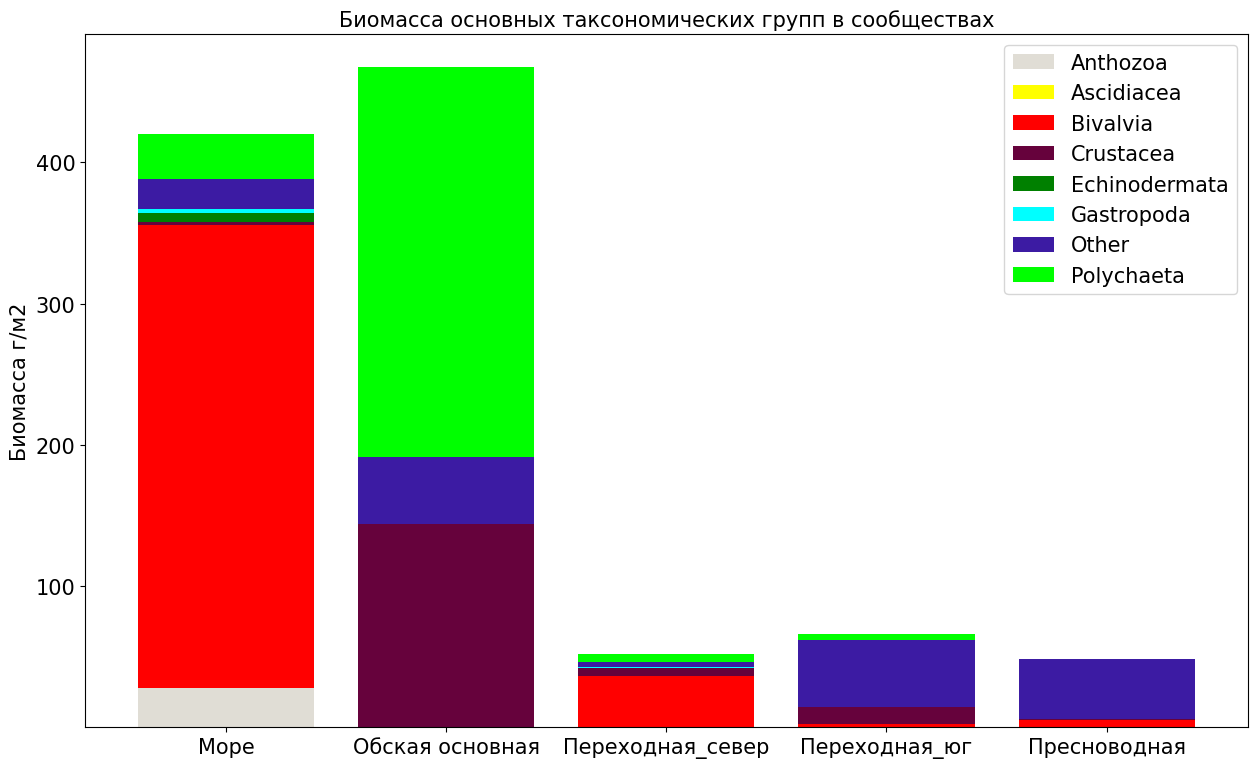

In [92]:
plt.figure(figsize=(15, 9)) 
start = 0
colors =  ['#e0ddd5', 'yellow', 'red',  '#66023C', 'green', 'cyan', '#3C1BA3', 'lime']
for i in range(len(d.columns)):
    if start == 0:
        plt.bar(d.index, d[d.columns[i]], label = d.columns[i], color=colors[i]) #,width = 0.5)
        bottom = d[d.columns[i]]
        start = 1
    else:
        plt.bar(d.index, d[d.columns[i]], bottom=bottom, label = d.columns[i], color=colors[i]) #,width = 0.5)
        bottom = bottom + d[d.columns[i]]

#plt.ylim(0,400)  
plt.ylabel('Биомасса г/м2', fontsize=15)        
plt.legend(loc='upper right', bbox_to_anchor=[1,1], fontsize=15)
plt.xticks(d.index, fontsize=15)
plt.yticks(fontsize='15')
plt.title('Биомасса основных таксономических групп в сообществах', fontsize= 15)
plt.savefig('02_pictures/15_barplot_kara_2.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

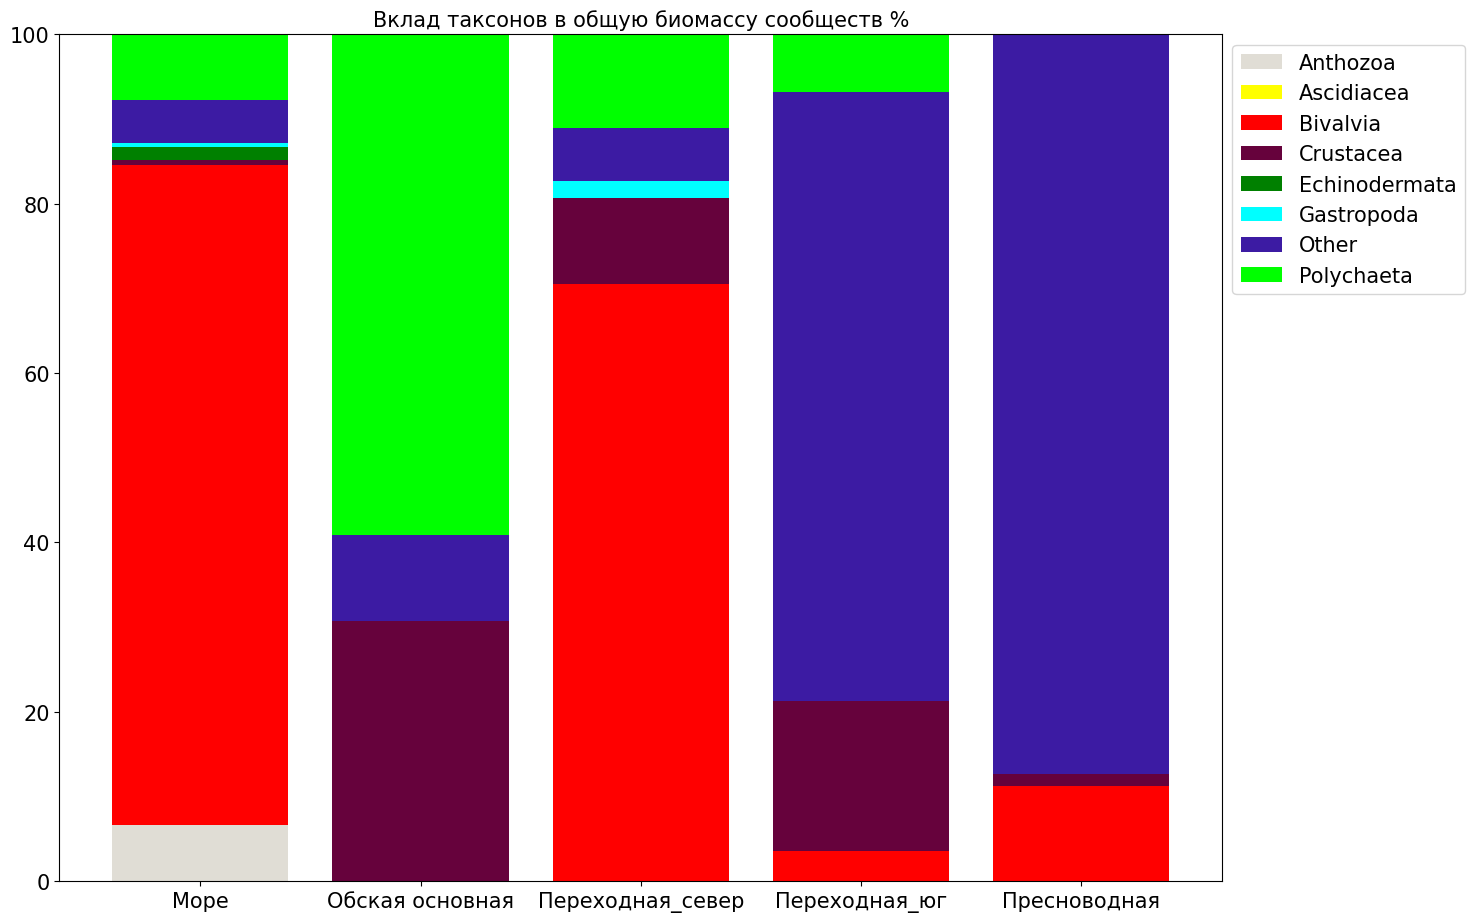

In [93]:
d2 = pd.DataFrame()
for i in d.T.columns:
    d2[i] = d.T[i] / d.T[i].sum() * 100
d2 = d2.T

plt.figure(figsize=(15, 11)) 
start = 0
for i in range(len(d2.columns)):
    if start == 0:
        plt.bar(d2.index, d2[d2.columns[i]], label = d2.columns[i], color=colors[i])
        bottom = d2[d2.columns[i]]
        start = 1
    else:
        plt.bar(d2.index, d2[d2.columns[i]], bottom=bottom, label = d2.columns[i], color=colors[i])
        bottom = bottom + d2[d2.columns[i]]
        
plt.legend(loc='upper left', bbox_to_anchor=[1, 1],fontsize='15')
plt.xticks(d2.index, fontsize='15')
plt.yticks(fontsize='15')
plt.title('Вклад таксонов в общую биомассу сообществ %', fontsize= '15')
plt.savefig('02_pictures/16_barplot_kara_1.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

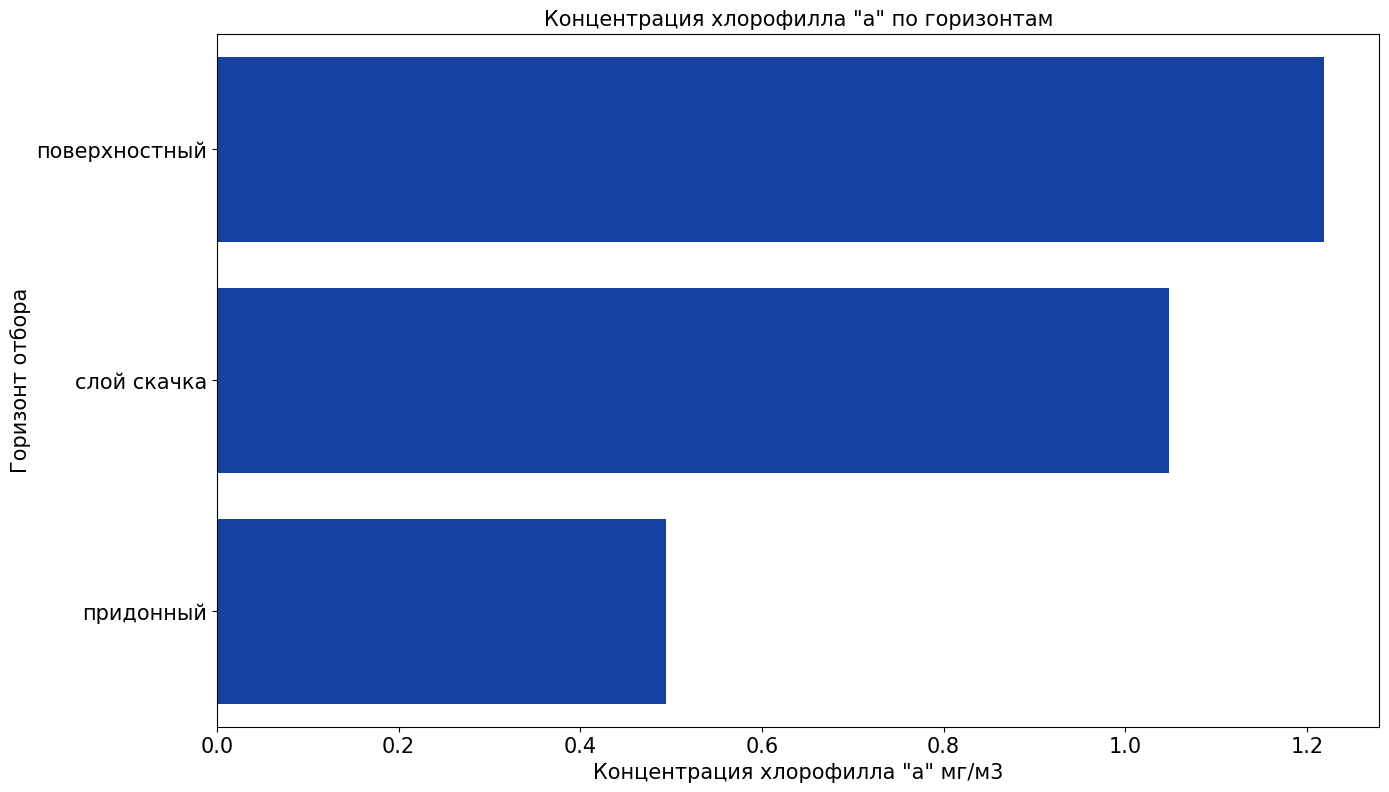

In [96]:
chlf = pd.read_excel('01_support_data/chlf_to_barplot_mg_to_m3.xlsx')
chlf = chlf[:29]

plt.figure(figsize=(15, 9))
sns.barplot(x=chlf['ChlA_conc'], y=chlf['Horizon'], ci=None, color='#0038B8')
plt.xlabel('Концентрация хлорофилла "а" мг/м3', fontsize=15)
plt.ylabel('Горизонт отбора', fontsize=15)
plt.xticks(fontsize = 15, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.yticks(fontsize='15')
plt.title('Концентрация хлорофилла "а" по горизонтам', fontsize=15)
plt.savefig('02_pictures/17_chlf_a_barplot.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

### Histplot, Scatterplot, Violinplot, Boxplot

In [98]:
data_ob = pd.read_csv('01_support_data/ob_env.csv')
data_ob.head()

,station,depth,temperature,salinity,sand,silt,lon,lat,sediment_class,salinity_class,depth_class,community,shannon,pielou,number_of_species,h3
0,1,-9.0,5.26130,15.958,26.5,73.3,74.142533,73.110033,Silt,5-16,8_15,Portlandia+Marenzellaria,0.770669,0.119009,8,850b4daffffffff
1,2,-15.0,-0.48520,29.344,0.8,99.2,73.528533,73.119300,Silt,>25,8_15,Pectinaria+Portlandia,2.025616,0.312801,6,850b4db7fffffff
2,3,-26.0,-0.98861,31.474,0.4,99.6,72.960700,73.130867,Silt,>25,>23,Pectinaria+Portlandia,2.031037,0.313638,21,850b4db7fffffff
3,4,-18.5,-0.72484,30.789,1.1,98.9,72.431367,73.140667,Silt,>25,15_20,Pectinaria+Portlandia,3.514632,0.542739,32,8500b647fffffff
4,5,-6.2,3.33740,25.189,61.0,38.8,71.921017,73.149683,Sand,>25,<8,Pectinaria+Portlandia,1.515002,0.233951,8,8500b60bfffffff


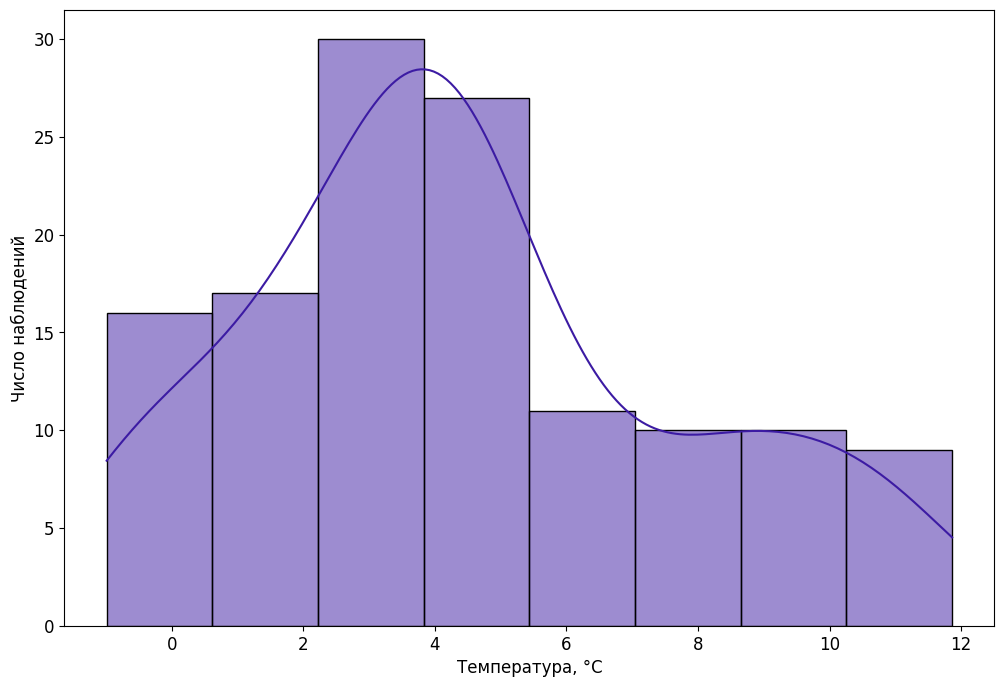

In [99]:
plt.figure(figsize=(12, 8))
sns.histplot(x=data_ob['temperature'], kde=True, stat = 'count', bins=8, color='#3C1BA3')
plt.xticks(fontsize='12')
plt.yticks(fontsize='12')
plt.xlabel('Температура, °С', fontsize=12)
plt.ylabel('Число наблюдений', fontsize=12)
plt.savefig('02_pictures/18_histplot.jpg', bbox_inches='tight', pad_inches = 0)

In [100]:
coms = pd.read_excel('01_support_data/Kara_AMK_base.xls', sheet_name='comm_east')
coms_dict = coms.set_index('Station')['Community'].to_dict()

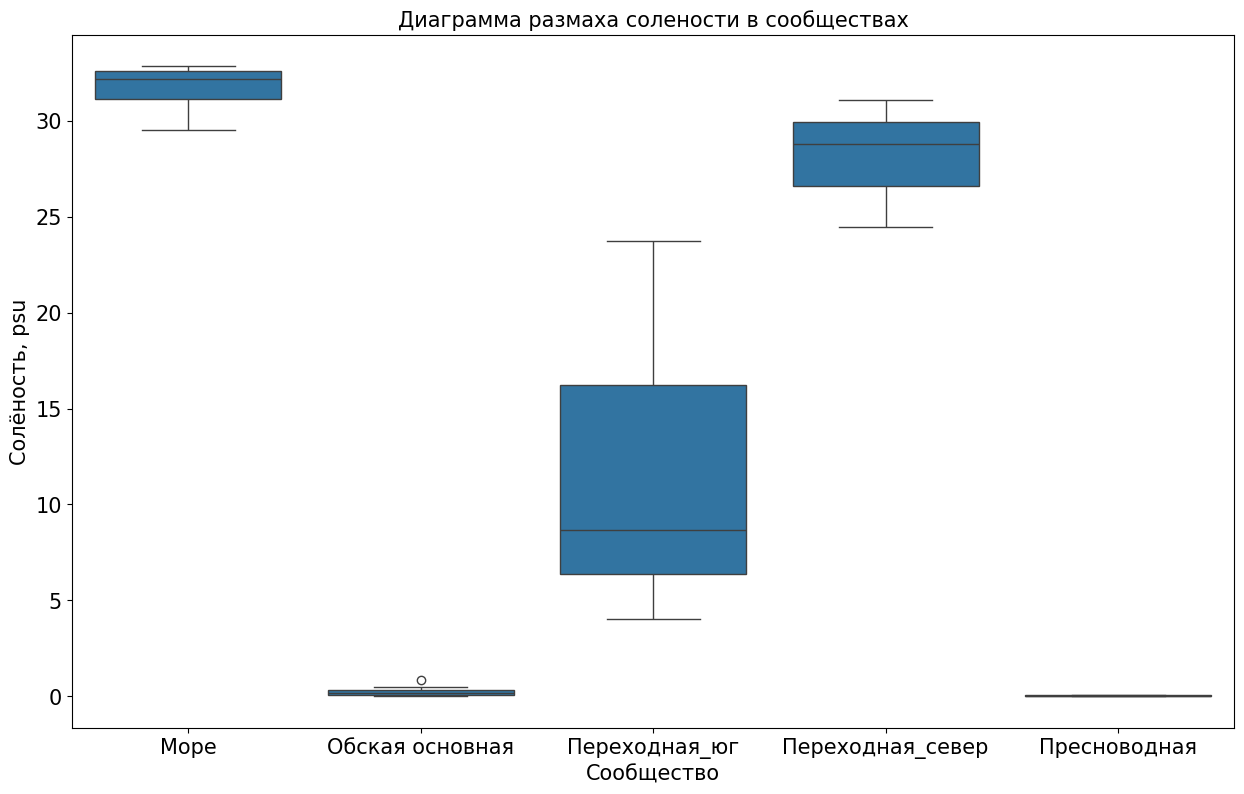

In [101]:
plt.figure(figsize=(15, 9))
sns.boxplot(x=coms['Community'], y=coms['Salinity']) 
plt.xlabel('Сообщество', fontsize=15)
plt.ylabel('Солёность, psu', fontsize=15)
plt.xticks(fontsize = 15, position = (-0.03, 0))#, rotation = 60) # настройка подписей
plt.yticks(fontsize = 15)
plt.title('Диаграмма размаха солености в сообществах', fontsize=15)
plt.savefig('02_pictures/19_boxplot_kara.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

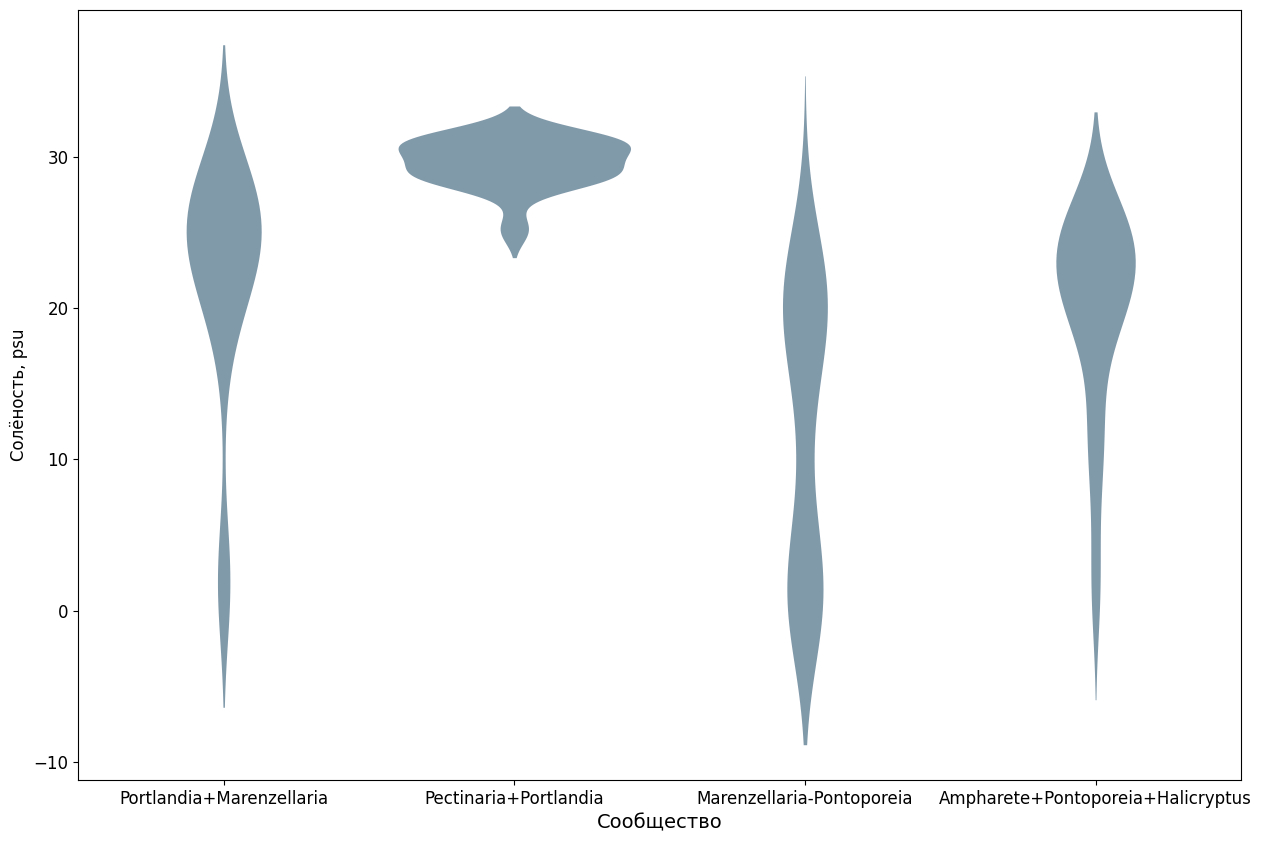

In [102]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=data_ob, x='community', y='salinity', inner=None, linewidth=0, saturation=0.4, alpha=0.7)
plt.xticks(fontsize='12')
plt.yticks(fontsize='12')
plt.xlabel('Сообщество', fontsize=14)
plt.ylabel('Солёность, psu', fontsize=12)
plt.savefig('02_pictures/20_violin.jpg', bbox_inches='tight', pad_inches = 0)

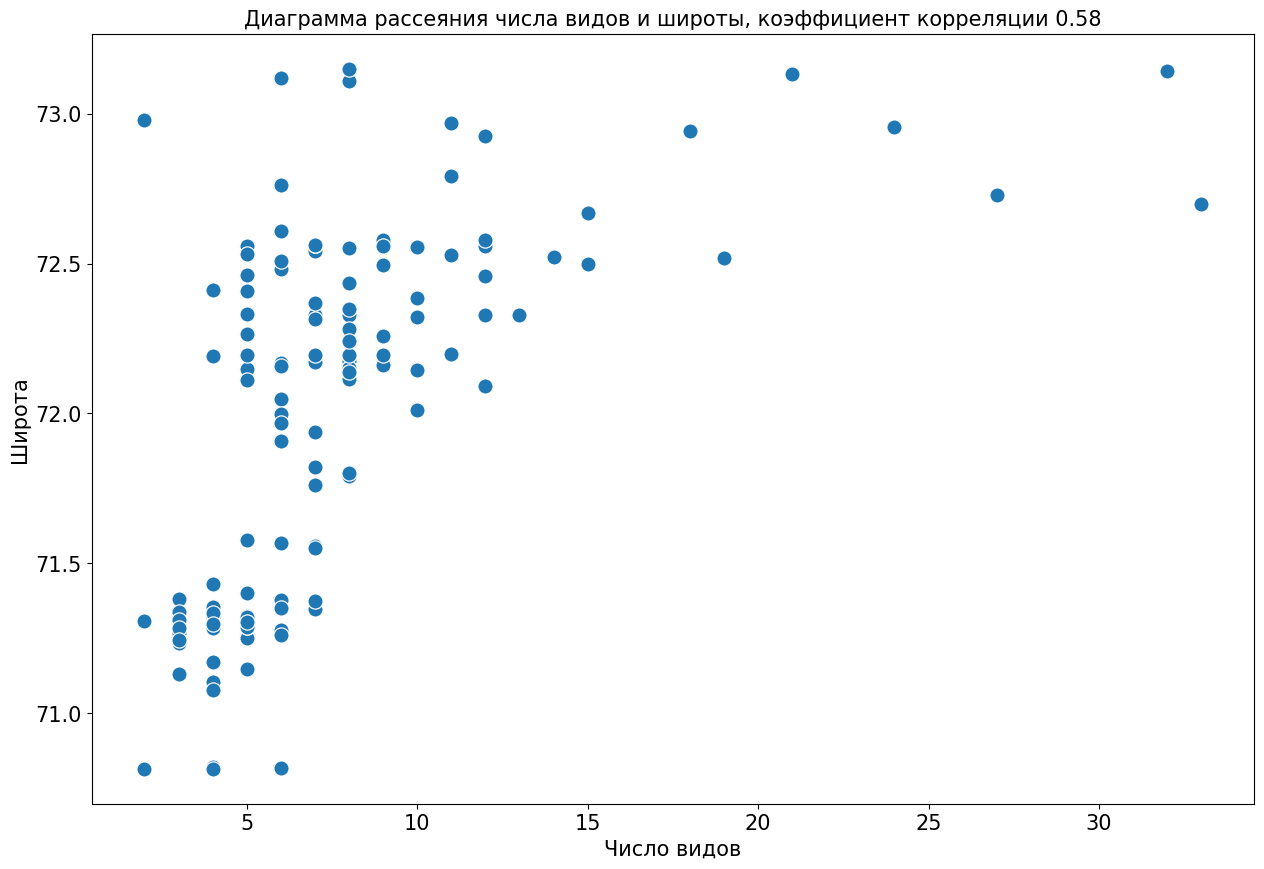

In [103]:
plt.figure(figsize=(15, 10))
sns.scatterplot(x=data_ob['number_of_species'], y=data_ob['lat'],s= 120)
plt.xticks(fontsize='15')
plt.yticks(fontsize='15')
plt.xlabel('Число видов', fontsize=15)
plt.ylabel('Широта', fontsize=15)
plt.title('Диаграмма рассеяния числа видов и широты, коэффициент корреляции ' + str(round(data_ob['number_of_species'].corr(data_ob['lat']), 2)), fontsize=15)
plt.savefig('02_pictures/21_scatter.jpg', bbox_inches='tight', pad_inches = 0)

### Combinated plots

<Figure size 1000x1000 with 0 Axes>

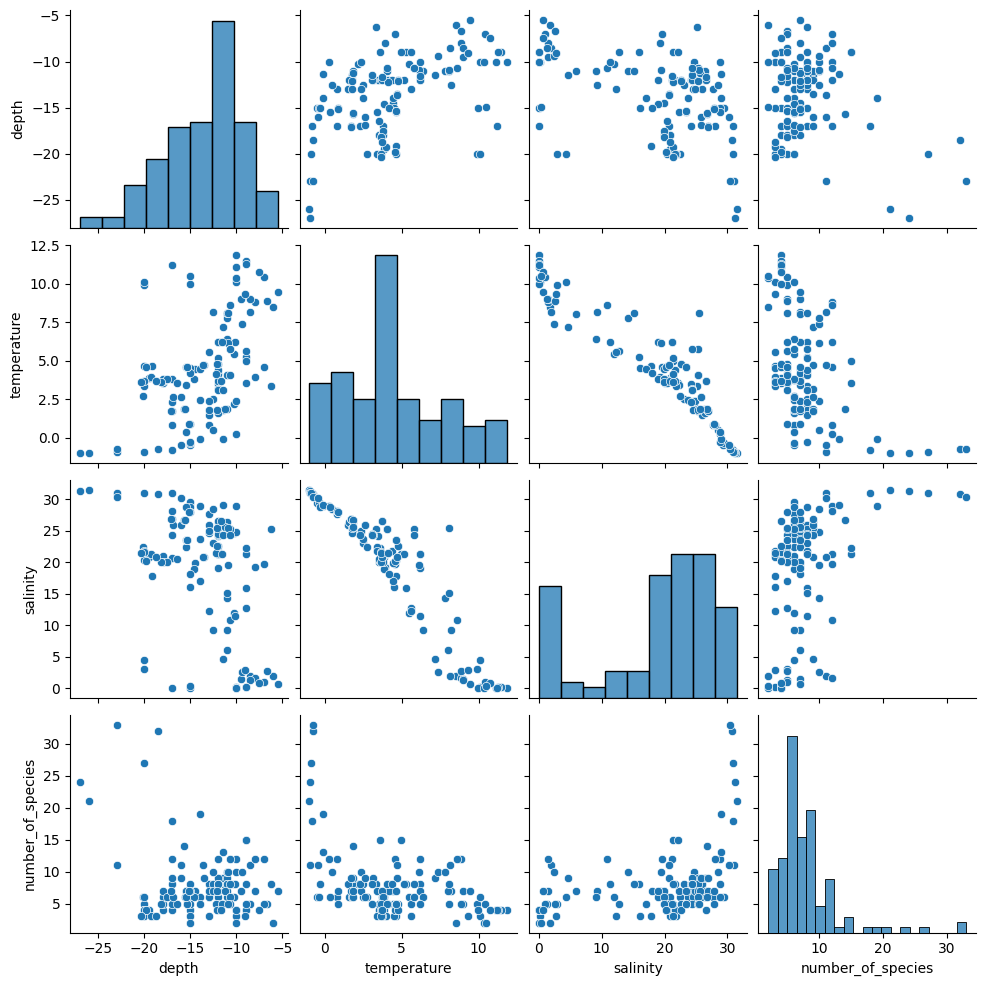

In [104]:
plt.figure(figsize=(10, 10))
data_ob_pair = data_ob[['depth', 'temperature', 'salinity', 'number_of_species']]
sns.pairplot(data_ob_pair)
plt.savefig('02_pictures/22_pairplot.jpg', bbox_inches='tight', pad_inches = 0)

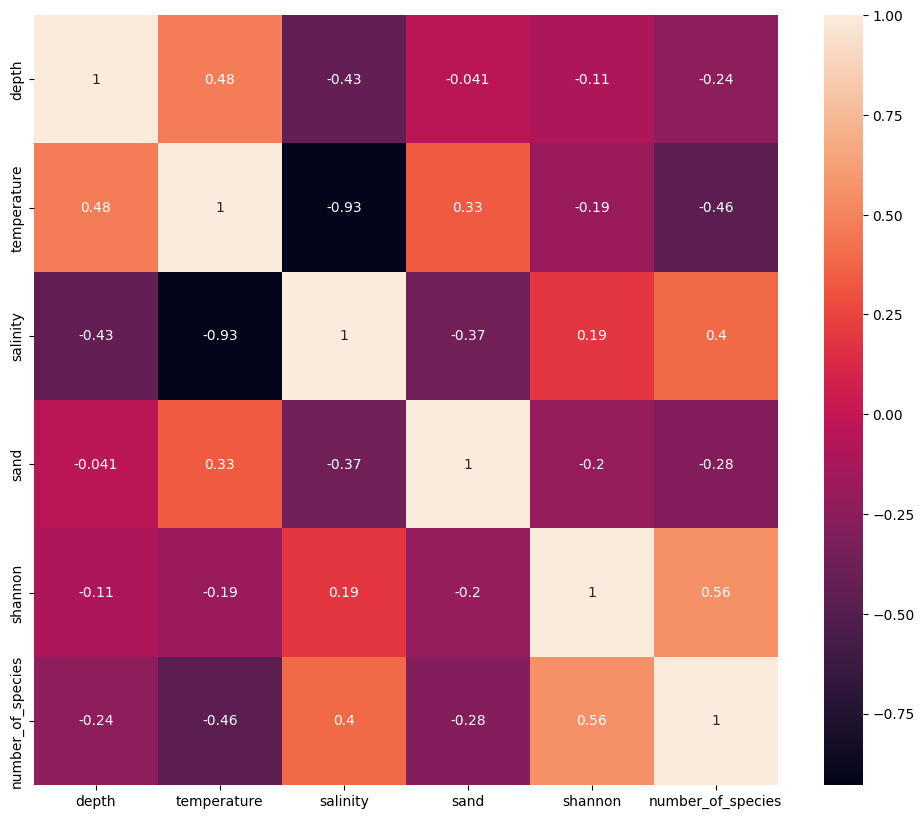

In [105]:
data_ob_hm = data_ob[['depth', 'temperature', 'salinity', 'sand', 'shannon', 'number_of_species']]
plt.figure(figsize=(12, 10))
sns.heatmap(data_ob_hm.corr(numeric_only=True), annot=True)
plt.savefig('02_pictures/23_heatmap.jpg', bbox_inches='tight', pad_inches = 0)

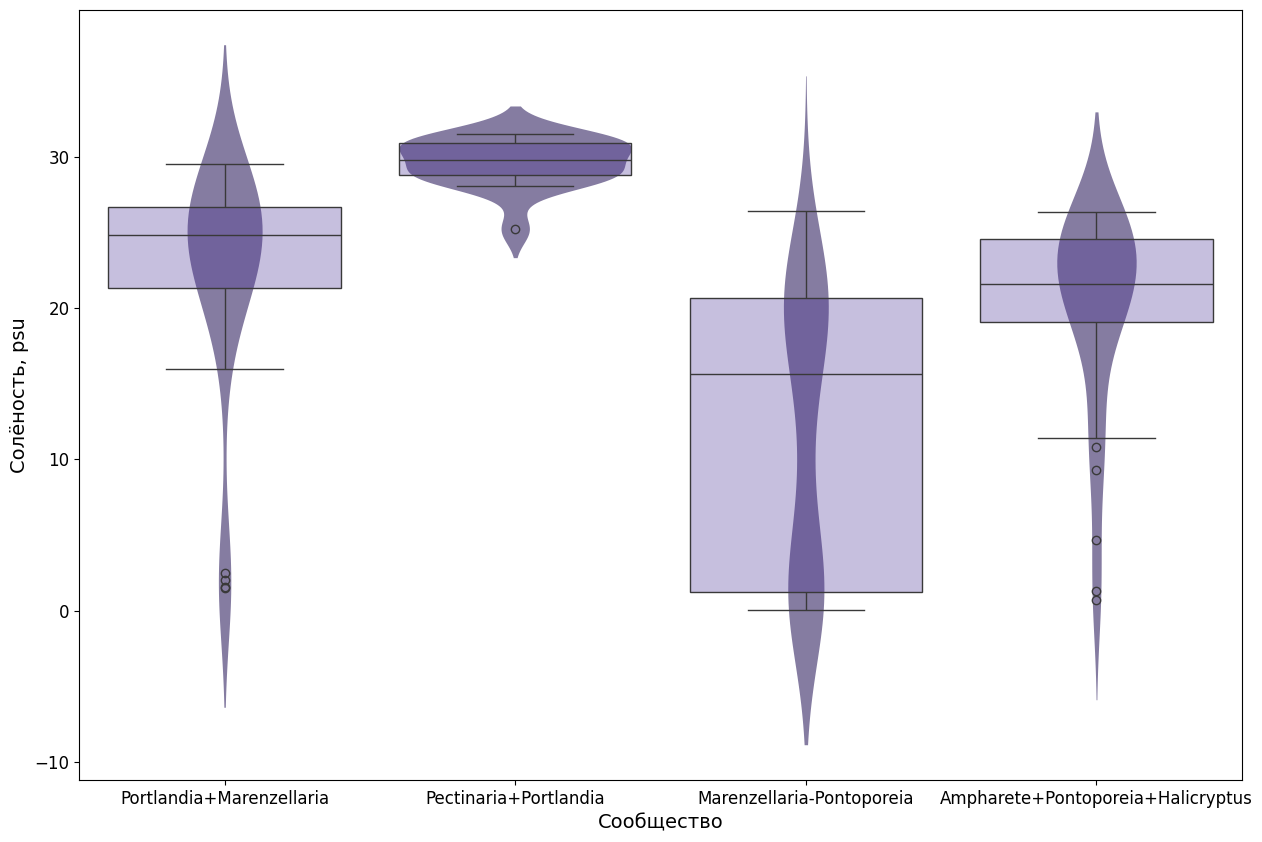

In [106]:
plt.figure(figsize=(15, 10))

ax = sns.boxplot(x='community', y='salinity', data=data_ob, color='#3C1BA3')
for patch in ax.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .3))
sns.violinplot(data=data_ob, x='community', y='salinity', inner=None, linewidth=0, saturation=0.4, ax=ax, alpha=0.7, color='#3C1BA3')
plt.xlabel('Сообщество', fontsize=14)
plt.ylabel('Солёность, psu', fontsize=14)
plt.xticks(fontsize = 12) #, position = (-0.03, 0), rotation = 60)
plt.yticks(fontsize = 12)
plt.savefig('02_pictures/24_combination_violin_box.jpg', bbox_inches='tight', pad_inches = 0)
plt.show()

### Specific plots

#### Radarplot

In [ ]:
import plotly.graph_objects as go
import plotly.express as px

from sklearn.preprocessing import MaxAbsScaler
from plotly.subplots import make_subplots

In [5]:
# make dataframe
df = pd.DataFrame({'число станций':[34,16,42,38],
                   'число видов':[36,68,19,22],
                   'численность':[629,617,593,893],
                   'биомасса':[37.68, 50.4, 11.57,14.39], 
                   'H`':[1.97, 2.33, 0.91, 1.62], 
                   'глубина':[2.9, 15.1, 6.1, 8.6],
                   'солёность': [21.9, 29.6, 12.0, 19.7]}, 
                   index=['Portlandia', 'Pectinaria', 'Marenzellaria', 'Ampharete'])

# here i used MaxAbsScaler scale features for graphical comfort
scaler = MaxAbsScaler()
scaler.fit(df)

d2 = pd.DataFrame(scaler.transform(df), columns=df.columns, index=df.index)
d2.head()

,число станций,число видов,численность,биомасса,H`,глубина,солёность
Portlandia,0.809524,0.529412,0.704367,0.747619,0.845494,0.192053,0.739865
Pectinaria,0.380952,1.000000,0.690929,1.000000,1.000000,1.000000,1.000000
Marenzellaria,1.000000,0.279412,0.664054,0.229563,0.390558,0.403974,0.405405
Ampharete,0.904762,0.323529,1.000000,0.285516,0.695279,0.569536,0.665541


In [6]:
d3 = d2.T
d3['theta'] = d3.index

In [7]:
# fixing possible troubles with plotly
# pip install kaleido==0.2.1
# pip install --upgrade nbformat

In [8]:
# make single plot with multiple data

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
      r=list(d3['Portlandia']),
      theta=d3['theta'],
      fill='toself',
      name='Portlandia',
      opacity=0.5,
))

fig.add_trace(go.Scatterpolar(
      r=list(d3['Pectinaria']),
      theta=d3['theta'],
      fill='toself',
      name='Pectinaria',
      opacity=0.5
))

fig.add_trace(go.Scatterpolar(
      r=list(d3['Ampharete']),
      theta=d3['theta'],
      fill='toself',
      name='Ampharete',
      opacity=0.5
))

fig.add_trace(go.Scatterpolar(
      r=list(d3['Marenzellaria']),
      theta=d3['theta'],
      fill='toself',
      name='Marenzellaria',
      opacity=0.5
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 1.2]
    )),
  showlegend=True
)
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.update_layout(
    font=dict(
        family="Helvetica", # Specify font family (can be multiple, comma-separated)
        size=14,                  # Set font size
        color="black"              # Set font color
    )
)

fig.write_image('02_pictures/25_Radar_benthos.jpg')
fig.show()

#### Sankey diogram

In [10]:
taxons = pd.read_excel('01_support_data/Kara_AMK_base.xls', sheet_name='b_for_visual_east_2', header=None)
taxons.columns = taxons.iloc[0]
taxons['Taxon'].value_counts()
def change_name(row):
    if row == 'Pantopoda' or row == 'Priapuloidea' or row == 'Sipuncoloidea' or row == 'Insecta' or row == 'Aplacophora' or row == 'Oligochaeta' or row == 'Echiuroidea' or row == 'Nemertini' or row == 'Bryozoa':
        return 'Other'
    else: 
        return row
taxons['Taxon'] = taxons['Taxon'].apply(change_name)
b = taxons[1:].groupby('Taxon').agg(['sum']).reset_index()
b.columns = b.columns.droplevel(1)
b.index = b['Taxon']
d2 = b.T.reset_index()[1:].groupby(0).agg(['sum'])
d2.columns = d2.columns.droplevel(1)
d2.head()

C:\Users\vladk\AppData\Local\Temp\ipykernel_11832\3235958179.py:10: PerformanceWarning:

indexing past lexsort depth may impact performance.



Taxon,Anthozoa,Ascidiacea,Bivalvia,Crustacea,Echinodermata,Gastropoda,Other,Polychaeta
0,,,,,,,,
Море,28.096,0.076,327.623861,2.288,6.418,2.232,21.327333,32.429994
Обская основная,0,0,0.033333,143.718547,0,0,47.579216,276.073448
Переходная_север,0.004,0,36.636446,5.248,0,1.018,3.25733,5.760641
Переходная_юг,0,0,2.387333,11.722,0,0,47.514395,4.509299
Пресноводная,0,0,5.43,0.68,0,0,42.19,0


In [16]:
import matplotlib

In [17]:
# define nodes
nodes = [
    d2.columns[0],         # 0
    d2.columns[1],          # 1
    d2.columns[2],   # 2
    d2.columns[3],    # 3
    d2.columns[4],        # 4
    d2.columns[5],      # 5
    d2.columns[6],        # 6
    d2.columns[7],        # 7
    d2.index[0],         # 8
    d2.index[1],     # 9
    d2.index[2],         # 10
    d2.index[3],  #11
    d2.index[4]       # 12
]

# define links (source, target, weight)
links = [
    {"source": 0, "target": 8, "value": d2[d2.columns[0]][d2.index[0]]},  
    {"source": 1, "target": 8, "value": d2[d2.columns[1]][d2.index[0]]},  
    {"source": 2, "target": 8, "value": d2[d2.columns[2]][d2.index[0]]},  
    {"source": 3, "target": 8, "value": d2[d2.columns[3]][d2.index[0]]},  
    {"source": 4, "target": 8, "value": d2[d2.columns[4]][d2.index[0]]}, 
    {"source": 5, "target": 8, "value": d2[d2.columns[5]][d2.index[0]]}, 
    {"source": 6, "target": 8, "value": d2[d2.columns[6]][d2.index[0]]},   
    {"source": 7, "target": 8, "value": d2[d2.columns[7]][d2.index[0]]},  
    
    {"source": 0, "target": 9, "value": d2[d2.columns[0]][d2.index[1]]},  
    {"source": 1, "target": 9, "value": d2[d2.columns[1]][d2.index[1]]},  
    {"source": 2, "target": 9, "value": d2[d2.columns[2]][d2.index[1]]},  
    {"source": 3, "target": 9, "value": d2[d2.columns[3]][d2.index[1]]},  
    {"source": 4, "target": 9, "value": d2[d2.columns[4]][d2.index[1]]}, 
    {"source": 5, "target": 9, "value": d2[d2.columns[5]][d2.index[1]]}, 
    {"source": 6, "target": 9, "value": d2[d2.columns[6]][d2.index[1]]},   
    {"source": 7, "target": 9, "value": d2[d2.columns[7]][d2.index[1]]}, 

    {"source": 0, "target": 10, "value": d2[d2.columns[0]][d2.index[2]]},  
    {"source": 1, "target": 10, "value": d2[d2.columns[1]][d2.index[2]]},  
    {"source": 2, "target": 10, "value": d2[d2.columns[2]][d2.index[2]]},  
    {"source": 3, "target": 10, "value": d2[d2.columns[3]][d2.index[2]]},  
    {"source": 4, "target": 10, "value": d2[d2.columns[4]][d2.index[2]]}, 
    {"source": 5, "target": 10, "value": d2[d2.columns[5]][d2.index[2]]}, 
    {"source": 6, "target": 10, "value": d2[d2.columns[6]][d2.index[2]]},   
    {"source": 7, "target": 10, "value": d2[d2.columns[7]][d2.index[2]]}, 

    {"source": 0, "target": 11, "value": d2[d2.columns[0]][d2.index[3]]},  
    {"source": 1, "target": 11, "value": d2[d2.columns[1]][d2.index[3]]},  
    {"source": 2, "target": 11, "value": d2[d2.columns[2]][d2.index[3]]},  
    {"source": 3, "target": 11, "value": d2[d2.columns[3]][d2.index[3]]},  
    {"source": 4, "target": 11, "value": d2[d2.columns[4]][d2.index[3]]}, 
    {"source": 5, "target": 11, "value": d2[d2.columns[5]][d2.index[3]]}, 
    {"source": 6, "target": 11, "value": d2[d2.columns[6]][d2.index[3]]},   
    {"source": 7, "target": 11, "value": d2[d2.columns[7]][d2.index[3]]}, 

    {"source": 0, "target": 12, "value": d2[d2.columns[0]][d2.index[4]]},  
    {"source": 1, "target": 12, "value": d2[d2.columns[1]][d2.index[4]]},  
    {"source": 2, "target": 12, "value": d2[d2.columns[2]][d2.index[4]]},  
    {"source": 3, "target": 12, "value": d2[d2.columns[3]][d2.index[4]]},  
    {"source": 4, "target": 12, "value": d2[d2.columns[4]][d2.index[4]]}, 
    {"source": 5, "target": 12, "value": d2[d2.columns[5]][d2.index[4]]}, 
    {"source": 6, "target": 12, "value": d2[d2.columns[6]][d2.index[4]]},   
    {"source": 7, "target": 12, "value": d2[d2.columns[7]][d2.index[4]]}, 
]

# extract source, target, and value lists for Sankey
source = [link['source'] for link in links]
target = [link['target'] for link in links]
value = [link['value'] for link in links]

# assign colors to nodes 
node_colors = [
    '#e0ddd5', #
    'yellow',  #
    'red',      # 
    '#66023C',      # 
    'green',      # 
    'cyan',# 
    '#3C1BA3', # 
    'lime',# 
    "blue", # 
    "cyan", # 
    "lime", # 
    "red", # 
    "magenta" # 
]


# assign colors to links
link_colors = [
    '#e0ddd5', #
    'yellow',  #
    'red',      # n
    '#66023C',      # 
    'green',      # 
    'cyan',# 
    '#3C1BA3', # 
    'lime',# 
    '#e0ddd5', #
    'yellow',  #
    'red',      # n
    '#66023C',      # 
    'green',      # 
    'cyan',# 
    '#3C1BA3', # 
    'lime',# 
    '#e0ddd5', #
    'yellow',  #
    'red',      # n
    '#66023C',      # 
    'green',      # 
    'cyan',# 
    '#3C1BA3', # 
    'lime',# 
    '#e0ddd5', #
    'yellow',  #
    'red',      # n
    '#66023C',      # 
    'green',      # 
    'cyan',# 
    '#3C1BA3', # 
    'lime',#     
    '#e0ddd5', #
    'yellow',  #
    'red',      # n
    '#66023C',      # 
    'green',      # 
    'cyan',# 
    '#3C1BA3', # 
    'lime'# 
]



# create  diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,  # Space between nodes
        thickness=20,  # Thickness of nodes
        line=dict(color="black", width=0.5),
        label=nodes,  # Node labels
        color=node_colors    # Node color
    ),
    link=dict(
        source=source,  # Sources of the links
        target=target,  # Targets of the links
        value=value,    # Weights of the links
        color=['rgba' + str(matplotlib.colors.to_rgba(i, alpha=0.6)) for i in link_colors]  # Link color (light blue)
    )
))

fig.update_layout(title_text="Диаграмма Сэнки - распределение биомассы таксонов по сообществам", font_size=13)
fig.update_layout(
    font=dict(
        family="Helvetica", # Specify font family (can be multiple, comma-separated)
        size=13,                  # Set font size
        color="black"              # Set font color
    )
)
fig.write_image('02_pictures/26_Sankey_benthos.jpg')
fig.show()

#### Treemap

In [19]:
df = pd.read_csv('01_support_data/treemap.csv', sep=';')
df['biom_sum_mg'] = pd.to_numeric(df['biom_sum_mg'].apply(lambda x: x.replace(',','.')))
df['biom_sum_g'] = df['biom_sum_mg']  / 1000
df.head()

,group,taxon,species,biom_sum_mg,count,biom_sum_g
0,Mollusca,Aplacophora,Chaetoderma nitidulum,109.666667,1,0.109667
1,Mollusca,Aplacophora,Chaetoderma sp.,154.333333,1,0.154333
2,Other,Ascidiacea,Ascidiacea gen. sp.,90.000000,1,0.090000
3,Other,Ascidiacea,Styellidae gen. sp.,36.000000,1,0.036000
4,Echinodermata,Asteroidea,Asteroidea juv.,8.666667,1,0.008667


In [20]:
fig = px.treemap(df, path=[px.Constant('group'), 'group', 'taxon'],
              values='biom_sum_g',
              color='biom_sum_g',
              color_continuous_scale='RdBu')
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.write_image("02_pictures/27_treemap_taxons.png")
fig.show()

#### Wordcloud

In [2]:
import nltk
import wordcloud

from nltk import word_tokenize
#from nltk.probability import FreqDist
from nltk.corpus import stopwords
#from nltk.stem import WordNetLemmatizer  
from wordcloud import WordCloud  
from PIL import Image

nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vladk\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vladk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\vladk\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
data = pd.read_csv('01_support_data/species.csv', sep=';', index_col=[0])
data['sum']=data.sum(axis=1)
data['weight'] = [int(data['sum'][i] / data['sum'].sum() * 1500) for i in range(len(data['sum']))]
data['name'] = data.index
data['name'] = data['name'].apply(lambda x: ' '.join(x.split()[:1]))
data.head()

,1,2,3,4,5,6,7,8,9,10,...,24,25,26,27,28,29,30,sum,weight,name
Chaetoderma nitidulum,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.051545,0.013567,0.058507,0.000000,0.0,0.093146,0.226504,2,Chaetoderma
Chaetoderma sp.,0.0,0.017059,0.001874,0.0,0.0,0.0,0.0,0.0,0.117143,0.000000,...,0.0,0.000000,0.000000,0.000000,0.085904,0.0,0.000000,0.255250,2,Chaetoderma
Ascidiacea gen. sp.,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.150754,1,Ascidiacea
Styellidae gen. sp.,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.039904,0.041284,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.081188,0,Styellidae
Asteroidea juv.,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.025666,0,Asteroidea


In [4]:
super_list = []
for i, n in zip(data['name'], data['weight']):
    super_list.append((i + ' ') * n)
union = ''.join(super_list)
union

'Chaetoderma Chaetoderma Chaetoderma Chaetoderma Ascidiacea Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Lophaster Lophaster Pontaster Pontaster Arctinula Arctinula Arctinula Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astart

In [5]:
text_tokens = word_tokenize(union)
text_tokens[:5]

['Chaetoderma', 'Chaetoderma', 'Chaetoderma', 'Chaetoderma', 'Ascidiacea']

In [6]:
# final text_raw for wordcloud
text_raw = " ".join(text_tokens)
text_raw

'Chaetoderma Chaetoderma Chaetoderma Chaetoderma Ascidiacea Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Ctenodiscus Lophaster Lophaster Pontaster Pontaster Arctinula Arctinula Arctinula Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astarte Astart

<function matplotlib.pyplot.show(close=None, block=None)>

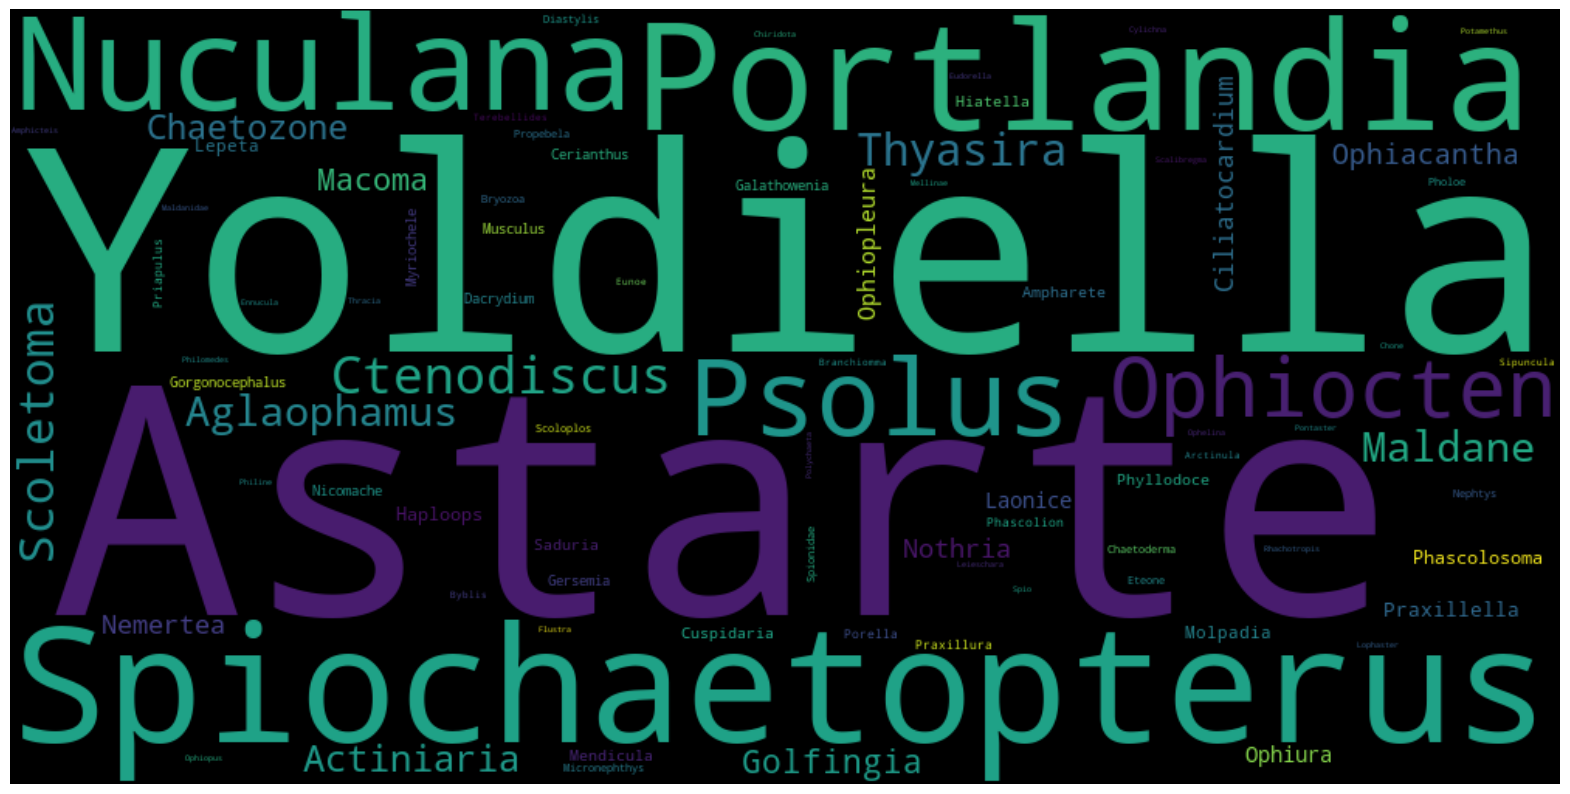

In [7]:
# simple wordcloud
plt.figure(figsize=(20,20))
WC=WordCloud(width=1000,height=500,max_words=100, min_font_size=5, collocations=False)
cloud=WC.generate(text_raw)
plt.imshow(cloud, interpolation='bilinear')
plt.axis("off")
#plt.savefig('11_worldcloud_species.jpg', bbox_inches='tight', pad_inches = 0)
plt.show

In [8]:
# wordcloud with mask
from PIL import Image
original_image = Image.open('01_support_data/kara_pres_wc.png')
#image = original_image.resize([1500,1000])
image = original_image
image = image.convert("L")
threshold = 50
image = image.point(
    lambda x: 255 if x > threshold else 0
)
image.show()

image = np.array(image)
image

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255],
       [  0,   0,   0, ..., 255, 255, 255]], dtype=uint8)

<function matplotlib.pyplot.show(close=None, block=None)>

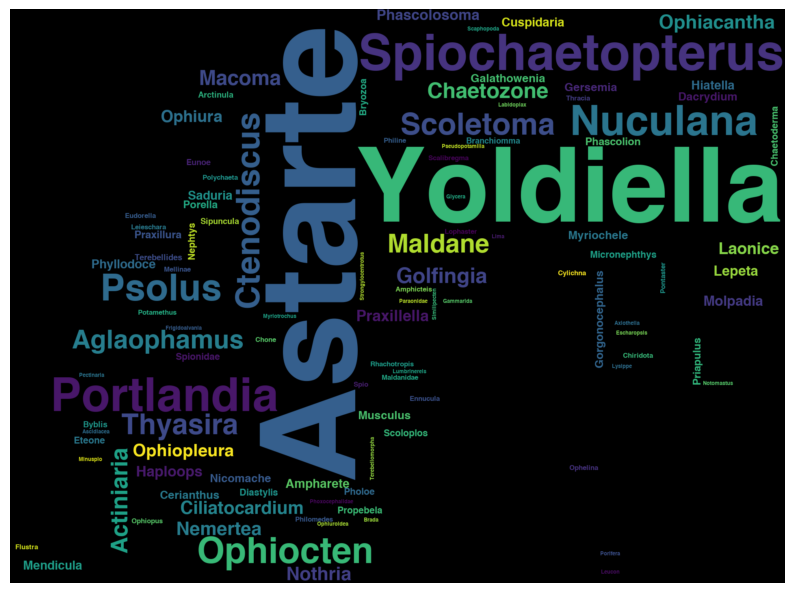

In [10]:
plt.figure(figsize=(10,10))
WC=WordCloud(font_path='01_support_data/Helvetica-Bold.ttf',
    width=original_image.size[0],height=original_image.size[1],max_words=500, min_font_size=5, mask=image, background_color='black', collocations=False)
cloud=WC.generate(text_raw)
plt.imshow(cloud, interpolation='bilinear')
plt.axis("off")
#plt.savefig('12_worldcloud_species_with_mask.jpg', bbox_inches='tight', pad_inches = 0)
plt.show

In [11]:
#  wordcloud with transparanse backgroud combination with other image
 
background_image = Image.open('01_support_data/kara_pres_wc.png').convert("RGBA")

#background_image = background_image.resize([1500, 1000])
#mask_image = mask_image.resize(background_image.size)

mask_image = background_image.convert("L")
threshold = 50
mask_image = mask_image.point(
    lambda x: 255 if x > threshold else 0
)
image = np.array(mask_image)

WC=WordCloud(font_path='01_support_data/Helvetica-Bold.ttf',
    width=background_image.size[0],height=background_image.size[1],max_words=500, min_font_size=5, mask=image, collocations=False, background_color=None, mode='RGBA', colormap='gist_yarg_r')#background_color='#D1D1D1')
cloud=WC.generate(text_raw)

wc_image = cloud.to_image()
#wc_image = wc_image.resize(background_image.size)
combined_image = Image.alpha_composite(background_image, wc_image)
combined_image.save('02_pictures/28_worldcloud_species_image_back.png')
combined_image.show()

## GIS data (some preparations of data and few approaches to vizualization)  

There are only few types of GIS visualization because main goal here is to show how aggregate data and use s2 or h3 cells, in case of most of GIS visuals it so more simple to show it using GIS soft directly (QGIS etc), so it is possble to make different preparation using python not only for cells but also for vessel tracks or other features  

Here about using s2 or h3 cells that could be usefull in analytics or even feature engineering also it is good for visualization due to cells have one "like-coordinate" system.  
s2 cells pushing by Google - it is quadrat cells with four sides every cell is neighbour to 8 cells around  
h3 cells pushing by Uber in general more popular - it is hexagon cells with six sides every cell is neighbour to 6 cells around  
  
below some average cells areas in dependence of their type and size (so also cell area depend by latitude)  

|Cell type|Cell size|Cell area $km^{2}$|
|:-------:|:-------:|:----------------:|
|h3|6|36|
|h3|7|5.2|
|h3|8|0.7|
|s2|10|81|
|s2|11|20|
|s2|12|5.1|

In [ ]:
# additional import

import geopandas as gpd
import h3
import json
import plotly.express as px
import xarray as xr

from s2sphere import CellId, LatLng, Cell
from shapely import Polygon

In [5]:
# here i use ncdf with xarray which demand path without cyrillic symbols
NC_PATH = 'C:/Users/vladk/NC_DATA/'

In [8]:
ds = xr.open_dataset(NC_PATH + 'gebco_2025_n55.3546_s53.7286_w7.2015_e9.1022.nc')
ds = ds.to_dataframe().reset_index()

# i use bathymetry from GEBCO but don't need data about elevation more than sea level
ds = ds.loc[ds['elevation'] <= 0]
ds

,lat,lon,elevation
0,53.731250,7.202083,-3
1,53.731250,7.206250,-3
2,53.731250,7.210417,-4
3,53.731250,7.214583,-4
4,53.731250,7.218750,-3
...,...,...,...
178116,55.352083,8.631250,0
178117,55.352083,8.635417,0
178118,55.352083,8.639583,0
178119,55.352083,8.643750,0


In [ ]:
# set sizes for h3 and s2 cells (h3: edge length 8.6 km, cell area - 252.9 km^2. s2: edge length 19.5 km, cell area 324.3 km^2)
# in presentation i also used 6 and 7 for h3 and 10, 11 for s2
RES_H3 = 8
RES_S2 = 12

In [10]:
# function to take h3-index from coordinates 

def convert_to_h3(lat, lon, res):
    h3_index = h3.latlng_to_cell(lat, lon, res)
    return h3_index

def h3_to_table(row):
    lat = row['lat']
    lon = row['lon']
    h3_index = convert_to_h3(lat, lon, RES_H3)
    return h3_index

In [11]:
# function to get s2 index from coordinates
def s2_to_table(row):
    lat = row['lat']
    lon = row['lon']
    cell_id = CellId.from_lat_lng(LatLng.from_degrees(lat, lon)).parent(RES_S2)
    return cell_id

In [12]:
def s2_index(data, level):
    s2_ind = []
    for lat, lon in zip(data['lat'], data['lon']):
        cell_id = CellId.from_lat_lng(LatLng.from_degrees(lat, lon)).parent(level)
        s2_ind.append(cell_id)
    return s2_ind

In [13]:
# function to get the vertices of an S2 cell
def get_s2_cell_vertices(cell_id):
    cell = Cell(cell_id)
    vertices = []
    # S2 cells have 4 vertices
    for i in range(4):  
        vertex = cell.get_vertex(i)
        latlng = LatLng.from_point(vertex)
        vertices.append((latlng.lat().degrees, latlng.lng().degrees))
    # close the polygon by repeating the first vertex
    vertices.append(vertices[0])
    return vertices

### apply function to get s2 and h3 indices

In [15]:
ds['h3'] = ds.apply(h3_to_table, axis=1)
ds.head()

,lat,lon,elevation,h3
0,53.73125,7.202083,-3,881f322927fffff
1,53.73125,7.206250,-3,881f322927fffff
2,53.73125,7.210417,-4,881f322927fffff
3,53.73125,7.214583,-4,881f3266c9fffff
4,53.73125,7.218750,-3,881f3266c9fffff


In [16]:
ds['s2'] = ds.apply(s2_to_table, axis=1)
ds.head()

,lat,lon,elevation,h3,s2
0,53.73125,7.202083,-3,881f322927fffff,CellId: 47b60fb000000000
1,53.73125,7.206250,-3,881f322927fffff,CellId: 47b60fb000000000
2,53.73125,7.210417,-4,881f322927fffff,CellId: 47b60fb000000000
3,53.73125,7.214583,-4,881f3266c9fffff,CellId: 47b60fb000000000
4,53.73125,7.218750,-3,881f3266c9fffff,CellId: 47b60fb000000000


### groupby H3 and S2

In [18]:
gruopby_s2 = ds.groupby('s2')['elevation'].agg('mean').reset_index()
print(gruopby_s2.shape)
gruopby_s2.head()

(4493, 2)


,s2,elevation
0,CellId: 4635535000000000,-25.769231
1,CellId: 4635537000000000,-25.972973
2,CellId: 4635539000000000,-26.500000
3,CellId: 463553b000000000,-27.000000
4,CellId: 463553d000000000,-27.750000


In [19]:
# get centroids of s2 cells (not for this case)
gruopby_s2['s2_center'] = gruopby_s2['s2'].apply(lambda x: x.to_lat_lng()) 
gruopby_s2['lat'] = gruopby_s2['s2_center'].apply(lambda x: x.lat().degrees)
gruopby_s2['lon'] = gruopby_s2['s2_center'].apply(lambda x: x.lng().degrees)
gruopby_s2 = gruopby_s2.drop('s2_center', axis=1)
gruopby_s2.head()

,s2,elevation,lat,lon
0,CellId: 4635535000000000,-25.769231,55.290151,7.206553
1,CellId: 4635537000000000,-25.972973,55.312033,7.212468
2,CellId: 4635539000000000,-26.500000,55.333920,7.218390
3,CellId: 463553b000000000,-27.000000,55.335695,7.188353
4,CellId: 463553d000000000,-27.750000,55.357590,7.194259


In [21]:
gruopby_h3 = ds.groupby('h3')['elevation'].agg('mean').reset_index()
print(gruopby_h3.shape)
gruopby_h3.head()

(31052, 2)


,h3,elevation
0,881f149201fffff,-1.0
1,881f149203fffff,-0.8
2,881f149205fffff,0.0
3,881f149207fffff,0.0
4,881f149209fffff,-3.2


In [22]:
# get centroids of h3 cells (not for this case)
gruopby_h3['h3_center'] = gruopby_h3['h3'].apply(lambda x: h3.cell_to_latlng(x)) #    old variants:   h3_to_geo      cellToLatLng 
gruopby_h3['h3_center'] = gruopby_h3['h3_center'].apply(lambda x: (x[1], x[0]))
gruopby_h3['lon'] = gruopby_h3['h3_center'].apply(lambda x: x[0])
gruopby_h3['lat']  = gruopby_h3['h3_center'].apply(lambda x: x[1])
gruopby_h3 = gruopby_h3.drop('h3_center', axis=1)
gruopby_h3.head()

,h3,elevation,lon,lat
0,881f149201fffff,-1.0,7.394717,53.741884
1,881f149203fffff,-0.8,7.407556,53.740925
2,881f149205fffff,0.0,7.385586,53.736046
3,881f149207fffff,0.0,7.398423,53.735088
4,881f149209fffff,-3.2,7.391009,53.748679


### prepare geojson

here i take boundaries of polygons  
h3 and s2 have other invert order of lat-lon and i need to change order to save it in geojson 

In [23]:
gruopby_s2['g_reflect'] = gruopby_s2['s2'].apply(lambda x: get_s2_cell_vertices(x))
gruopby_s2.head()

,s2,elevation,lat,lon,g_reflect
0,CellId: 4635535000000000,-25.769231,55.290151,7.206553,"[(55.27832434523213, 7.218591116635024), (55.3..."
1,CellId: 4635537000000000,-25.972973,55.312033,7.212468,"[(55.30020212170593, 7.224513339904664), (55.3..."
2,CellId: 4635539000000000,-26.500000,55.333920,7.218390,"[(55.32208507611135, 7.230443580118673), (55.3..."
3,CellId: 463553b000000000,-27.000000,55.335695,7.188353,"[(55.32386389927437, 7.200414193098351), (55.3..."
4,CellId: 463553d000000000,-27.750000,55.357590,7.194259,"[(55.345754418002144, 7.206328326265593), (55...."


In [26]:
result_g2 = []
for i in gruopby_s2['g_reflect']:
    iter = []
    for a in i:
        int = tuple([a[1], a[0]])
        iter.append(int)
    iter = tuple(iter)
    c = Polygon(iter)
    polygon = Polygon(iter)
    result_g2.append(c)
gruopby_s2['geometry'] = result_g2
gruopby_s2 = gruopby_s2.drop('g_reflect', axis=1)
gruopby_s2.head()

,s2,elevation,lat,lon,geometry
0,CellId: 4635535000000000,-25.769231,55.290151,7.206553,"POLYGON ((7.218591116635024 55.27832434523213,..."
1,CellId: 4635537000000000,-25.972973,55.312033,7.212468,"POLYGON ((7.224513339904664 55.30020212170593,..."
2,CellId: 4635539000000000,-26.500000,55.333920,7.218390,"POLYGON ((7.230443580118673 55.32208507611135,..."
3,CellId: 463553b000000000,-27.000000,55.335695,7.188353,"POLYGON ((7.200414193098351 55.32386389927437,..."
4,CellId: 463553d000000000,-27.750000,55.357590,7.194259,POLYGON ((7.206328326265593 55.345754418002144...


In [27]:
gruopby_h3['g_reflect'] = gruopby_h3['h3'].apply(lambda x: h3.cell_to_boundary(x))   # old variant  cellToBoundary 
gruopby_h3.head()

,h3,elevation,lon,lat,g_reflect
0,881f149201fffff,-1.0,7.394717,53.741884,"((53.74446809936094, 7.389201189229811), (53.7..."
1,881f149203fffff,-0.8,7.407556,53.740925,"((53.74350994571991, 7.402040647509234), (53.7..."
2,881f149205fffff,0.0,7.385586,53.736046,"((53.73863036078299, 7.380070609175867), (53.7..."
3,881f149207fffff,0.0,7.398423,53.735088,"((53.73767290938531, 7.3929083710210435), (53...."
4,881f149209fffff,-3.2,7.391009,53.748679,"((53.75126229495757, 7.3854932885524915), (53...."


In [28]:
result_g2 = []
for i in gruopby_h3['g_reflect']:
    iter = []
    for a in i:
        int = tuple([a[1], a[0]])
        iter.append(int)
    iter = tuple(iter)
    c = Polygon(iter)
    polygon = Polygon(iter)
    result_g2.append(c)
gruopby_h3['geometry'] = result_g2
gruopby_h3 = gruopby_h3.drop('g_reflect', axis=1)
gruopby_h3.head()

,h3,elevation,lon,lat,geometry
0,881f149201fffff,-1.0,7.394717,53.741884,"POLYGON ((7.389201189229811 53.74446809936094,..."
1,881f149203fffff,-0.8,7.407556,53.740925,"POLYGON ((7.402040647509234 53.74350994571991,..."
2,881f149205fffff,0.0,7.385586,53.736046,"POLYGON ((7.380070609175867 53.73863036078299,..."
3,881f149207fffff,0.0,7.398423,53.735088,POLYGON ((7.3929083710210435 53.73767290938531...
4,881f149209fffff,-3.2,7.391009,53.748679,POLYGON ((7.3854932885524915 53.75126229495757...


In [29]:
# save dataframes into .geojson (or in .parquet for example it could be more useful sometimes) for use it in GIS or in other purposes
gruopby_s2 = gpd.GeoDataFrame(gruopby_s2, geometry=gruopby_s2['geometry'], crs="EPSG:4326")
# gruopby_s2.to_file('02_pictures/s2_north' + str(RES_S2) +'.geojson', driver="GeoJSON")
gruopby_h3 = gpd.GeoDataFrame(gruopby_h3, geometry=gruopby_h3['geometry'], crs="EPSG:4326")
# gruopby_h3.to_file('02_pictures/h3_north' + str(RES_H3) + '.geojson', driver="GeoJSON")

below short visualization (not for presentation in that case i used QGIS - this is just example)  
usualy i make hexagon maps in QGIS, sometimes in Folium, here example with plotly

In [ ]:
# before i used folium to represent h3 cells, now i try to use plotly with geojson 
# it is faster and having more simple code but it is needable to obtain "geojson_data" as below

# id col       
gruopby_h3['id'] = gruopby_h3.index             

# assign 'id' to every GeoJSON feature:
geojson_data = json.loads(gruopby_h3.to_json())
for i, feature in enumerate(geojson_data['features']):
    feature['id'] = gruopby_h3['id'][i]

final cell is commented out in notebook due to sizes, so it is possible to run it

In [1]:
# drawing hexmap with plotly
'''
fig = px.choropleth_mapbox(
    gruopby_h3,
    geojson=geojson_data,
    locations="id",
    color="elevation",
    color_continuous_scale = 'Jet',
    mapbox_style="open-street-map",
    center={"lat": gruopby_h3.geometry.centroid.y.mean(),
            "lon": gruopby_h3.geometry.centroid.x.mean()},
    zoom=7,
    opacity=0.3, width=1200, height=800
)
fig.write_image("02_pictures/29_example_bathymetry_h3_map_size_8.png")
fig.show()
'''

'\nfig = px.choropleth_mapbox(\n    gruopby_h3,\n    geojson=geojson_data,\n    locations="id",\n    color="elevation",\n    color_continuous_scale = \'Jet\',\n    mapbox_style="open-street-map",\n    center={"lat": gruopby_h3.geometry.centroid.y.mean(),\n            "lon": gruopby_h3.geometry.centroid.x.mean()},\n    zoom=7,\n    opacity=0.3, width=1200, height=800\n)\nfig.write_image("02_pictures/29_example_bathymetry_h3_map_size_8.png")\nfig.show()\n'